# Project 02 · Customer Churn AI
## EDA → Feature Engineering → Feature Selection → Model Comparison → Hyperparameter Tuning → Final Model


데이터셋: **IBM Telco Customer Churn** (`ai-server/data/ibm_telco.csv`)

Target: **Churn Label** (고객이 이탈했는가? Yes / No) → Classification(분류) 문제



```text
EDA
  ↓
Hypothesis (가설 수립)
  ↓
Feature Engineering (파생변수 생성)
  ↓
Feature Selection
  ↓
Train / Test Split
  ↓
Model Comparison (Logistic Regression, Decision Tree, Random Forest)
  ↓
Hyperparameter Tuning
  ↓
Final Model
  ↓
Research Report
```


---
# Chapter 1. 프로젝트 소개


## Customer Churn이란?

**Customer Churn(고객 이탈)** 이란 고객이 더 이상 우리 서비스(통신사, 구독 서비스 등)를
이용하지 않고 떠나는 것을 의미합니다.

통신사(Telco) 입장에서 고객 한 명을 잃는 것은 단순히 "고객 한 명이 줄어드는 것" 이상의 의미를
가집니다.

- 새로운 고객을 데려오는 비용(마케팅비)은 기존 고객을 유지하는 비용보다 훨씬 비쌉니다.
- 이탈한 고객은 대부분 경쟁사로 이동하기 때문에, 매출 손실이 곧바로 경쟁사의 이익이 됩니다.
- 이탈 직전 고객을 미리 찾아낼 수 있다면, 할인/혜택 등으로 이탈을 막을 수 있는 "골든 타임"이
  생깁니다.

그래서 "누가 이탈할 가능성이 높은가?"를 미리 예측하는 모델은 실무에서 매우 중요하게 사용됩니다.



## 머신러닝 Workflow


```text
데이터 수집
    ↓
EDA (탐색적 데이터 분석)
    ↓
Hypothesis (가설 수립)
    ↓
Feature Engineering (파생변수 생성)
    ↓
Feature Selection (불필요한 Feature 제거)
    ↓
Train / Test Split
    ↓
Model Comparison (여러 모델 비교)
    ↓
Hyperparameter Tuning (최적 파라미터 탐색)
    ↓
Final Model (최종 모델 선정 및 저장)
```

## Feature Engineering의 목적

원본 데이터의 컬럼(예: `Tenure in Months`, `Monthly Charge`)을 그대로 쓰는 것보다,
컬럼들을 조합하거나 가공해서 **모델이 패턴을 더 쉽게 학습할 수 있는 형태**로 바꿔주는 작업입니다.

예를 들어 "월 단위 계약이면서 동시에 신규 고객인 경우" 처럼 두 조건이 겹칠 때만 나타나는
위험 신호는, 원본 컬럼 두 개를 각각 보는 것보다 하나의 파생변수로 만들어주면 모델이 훨씬
더 쉽게 학습합니다.

## Feature Selection의 목적

Feature Engineering으로 파생변수를 많이 만들다 보면, 오히려 서로 비슷한 정보를 담은
중복 Feature가 늘어나거나, Target과 거의 관련이 없는 Feature가 섞이게 됩니다.

Feature Selection은 이렇게 늘어난 Feature 중에서

- 분산이 없어 정보량이 없는 Feature
- 다른 Feature와 거의 동일한 정보를 담은(높은 상관관계) Feature
- Target 예측에 통계적으로 기여하지 않는 Feature



---
# Chapter 2. EDA (Exploratory Data Analysis, 탐색적 데이터 분석)


## EDA를 왜 하는가?

머신러닝 모델은 "데이터를 있는 그대로" 학습합니다. 그래서 데이터에 문제가 있으면
(결측치, 이상치, 잘못 입력된 값 등) 모델도 잘못된 패턴을 학습하게 됩니다.

EDA는 본격적으로 모델을 학습시키기 **전에**, 데이터가 어떻게 생겼는지 먼저 이해하는
과정입니다. "요리를 하기 전에 재료 상태를 먼저 확인하는 것"과 같습니다.

EDA를 통해 우리는 다음 질문에 답할 수 있어야 합니다.

- 이 데이터는 몇 명의 고객, 몇 개의 정보(컬럼)로 이루어져 있는가?
- 비어있는 값(결측치)은 없는가? 있다면 왜 비어있는가?
- 중복된 고객 데이터는 없는가?
- 숫자형 변수들은 어떤 분포를 가지는가? 한쪽으로 치우쳐(Skewed) 있지는 않은가?
- 범주형 변수들은 어떤 값을 가장 많이 가지는가?
- Target(Churn Label)과 각 Feature는 어떤 관계가 있는가?

이제 실제 데이터를 불러오겠습니다.

In [146]:
# ---------------------------------------------------------------
# 라이브러리 불러오기
# ---------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline  

# 1. seaborn 그래프 기본 스타일
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

# 2. OS별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux, Colab, Ubuntu
    plt.rcParams["font.family"] = "NanumGothic"

# 3. 기타 Matplotlib 설정
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

pd.set_option("display.max_columns", 100)

In [147]:
# ---------------------------------------------------------------
# 데이터 불러오기
# 이 Notebook은 ai-server/notebooks/ 안에 있으므로,
# 데이터 파일은 한 단계 위(../data)에 있습니다.
# ---------------------------------------------------------------
DATA_PATH = "../data/ibm_telco.csv"

df = pd.read_csv(DATA_PATH)

print("데이터 로드 완료")
print("행(Row) 개수, 열(Column) 개수 :", df.shape)
print(df.head())

데이터 로드 완료
행(Row) 개수, 열(Column) 개수 : (7043, 50)
  Customer ID  Gender  Age Under 30 Senior Citizen Married Dependents  \
0  8779-QRDMV    Male   78       No            Yes      No         No   
1  7495-OOKFY  Female   74       No            Yes     Yes        Yes   
2  1658-BYGOY    Male   71       No            Yes      No        Yes   
3  4598-XLKNJ  Female   78       No            Yes     Yes        Yes   
4  4846-WHAFZ  Female   80       No            Yes     Yes        Yes   

   Number of Dependents        Country       State         City  Zip Code  \
0                     0  United States  California  Los Angeles     90022   
1                     1  United States  California  Los Angeles     90063   
2                     3  United States  California  Los Angeles     90065   
3                     1  United States  California    Inglewood     90303   
4                     1  United States  California     Whittier     90602   

    Latitude   Longitude  Population Quarter Referr

## 2-1. Shape 확인

`df.shape`는 `(행 개수, 열 개수)` 형태의 튜플을 반환합니다.



In [148]:
df.shape

(7043, 50)

## 2-2. info() 확인


`df.info()` 는 다음 정보를 한 번에 보여줍니다.

- 각 컬럼의 이름
- 각 컬럼의 **dtype(데이터 타입)**: 숫자형(`int64`, `float64`)인지 문자형(`object`)인지
- **결측치가 아닌 값의 개수(Non-Null Count)**: 이 값이 전체 행 개수(7,043)보다 작으면
  결측치가 있다는 뜻입니다.
- **Memory Usage(메모리 사용량)**: 데이터가 차지하는 메모리 크기


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

## 2-3. describe() - 5수 요약(Five-Number Summary)

`df.describe()` 는 숫자형 컬럼에 대해 다음 통계량을 보여줍니다.

| 통계량 | 의미 |
|---|---|
| count | 값이 있는 데이터 개수 |
| mean | 평균 |
| std | 표준편차 (데이터가 평균으로부터 얼마나 퍼져 있는가) |
| min | 최솟값 |
| 25% | 하위 25%가 이 값보다 작음 (1사분위수) |
| 50% | 중앙값 (Median) |
| 75% | 하위 75%가 이 값보다 작음 (3사분위수) |
| max | 최댓값 |


In [150]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [151]:
# 문자형(범주형) 컬럼의 요약 통계도 함께 확인합니다.
# top: 가장 많이 등장한 값, freq: 그 값이 등장한 횟수
df.describe(include="object")

,Customer ID,Gender,Under 30,Senior Citizen,Married,Dependents,Country,State,City,Quarter,Referred a Friend,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status,Churn Label,Churn Category,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,3166,7043,7043,7043,5517,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869,1869
unique,7043,2,2,2,2,2,1,1,1106,1,2,5,2,2,2,3,2,2,2,2,2,2,2,2,3,2,3,3,2,5,20
top,8779-QRDMV,Male,No,No,No,No,United States,California,Los Angeles,Q3,No,Offer B,Yes,No,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Stayed,No,Competitor,Competitor had better devices
freq,1,3555,5642,5901,3641,5416,7043,7043,293,7043,3821,824,6361,4072,5517,3035,5024,4614,4621,4999,4336,4311,4555,4745,3610,4171,3909,4720,5174,841,313


## 2-4. 결측치(Missing Value)

**결측치(Missing Value)** 는 데이터에 값이 채워지지 않고 비어있는 상태(`NaN`)를 말합니다.



In [152]:
# 컬럼별 결측치 개수 확인
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("결측치가 있는 컬럼:")
print(missing)

print("\n결측치 비율(%):")
print((missing / len(df) * 100).round(2))

결측치가 있는 컬럼:
Churn Category    5174
Churn Reason      5174
Offer             3877
Internet Type     1526
dtype: int64

결측치 비율(%):
Churn Category    73.46
Churn Reason      73.46
Offer             55.05
Internet Type     21.67
dtype: float64


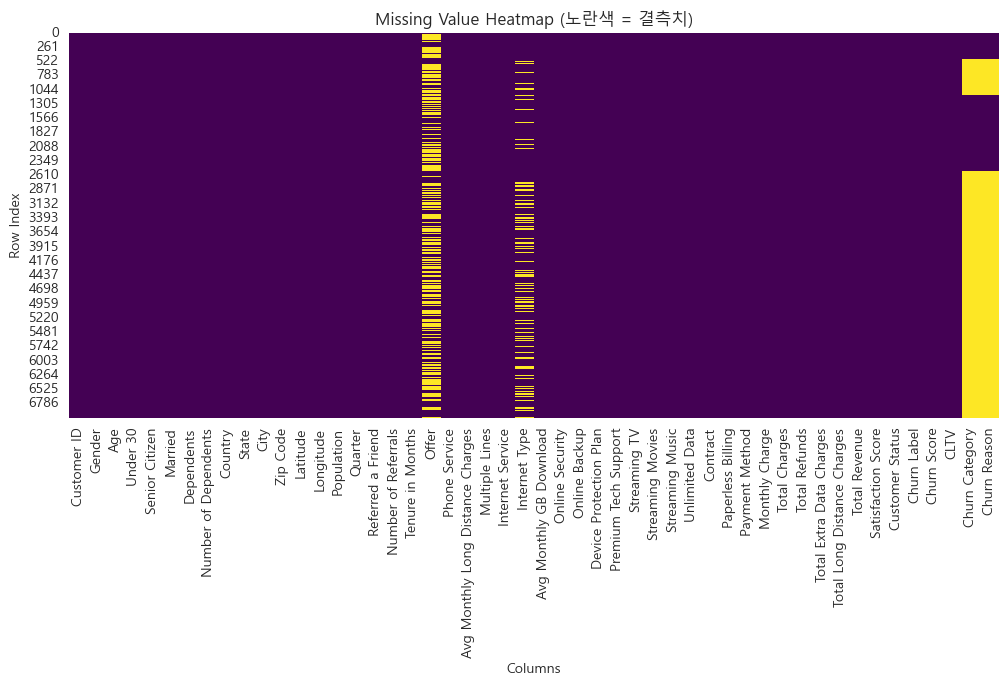

In [153]:
# 결측치 위치를 heatmap으로 시각화합니다.
# (노란색 = 결측치가 있는 위치)
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap (노란색 = 결측치)")
plt.xlabel("Columns")
plt.ylabel("Row Index")
plt.show()

## 2-5. 중복 데이터(Duplicate)

중복 데이터는 크게 두 가지로 확인합니다.

1. **완전히 동일한 행(Row)이 중복되는 경우**
2. **고객 식별자(Customer ID)만 중복되는 경우** (같은 고객이 두 번 이상 기록된 경우)


In [154]:
# 완전히 동일한 행이 몇 개인지 확인
duplicate_rows = df.duplicated().sum()
print("완전히 중복된 행 개수 :", duplicate_rows)

# Customer ID 기준 중복 확인
duplicate_ids = df["Customer ID"].duplicated().sum()
print("중복된 Customer ID 개수 :", duplicate_ids)

print("\n중복 제거 전 데이터 크기 :", df.shape)
# 이 데이터셋에는 중복이 없으므로 drop_duplicates()를 실행해도 크기가 그대로입니다.
df_check = df.drop_duplicates()
print("중복 제거 후 데이터 크기 :", df_check.shape)

완전히 중복된 행 개수 : 0
중복된 Customer ID 개수 : 0

중복 제거 전 데이터 크기 : (7043, 50)
중복 제거 후 데이터 크기 : (7043, 50)


## 2-6. Target 분석 (Churn Label)

`Churn Label` 값을 분석에 사용하기 위해 `Yes` → 1, `No` → 0 으로 변환합니다.
이후 이탈 고객 수, 잔류 고객 수, 이탈률, 클래스 비율을 확인합니다.


In [155]:
# Target을 숫자로 변환 (Yes -> 1, No -> 0)
df["Churn"] = df["Churn Label"].map({"Yes": 1, "No": 0})

print("이탈(1) / 잔류(0) 고객 수:")
print(df["Churn"].value_counts())

print("\n이탈(1) / 잔류(0) 비율:")
print(df["Churn"].value_counts(normalize=True).round(4))

이탈(1) / 잔류(0) 고객 수:
Churn
0    5174
1    1869
Name: count, dtype: int64

이탈(1) / 잔류(0) 비율:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


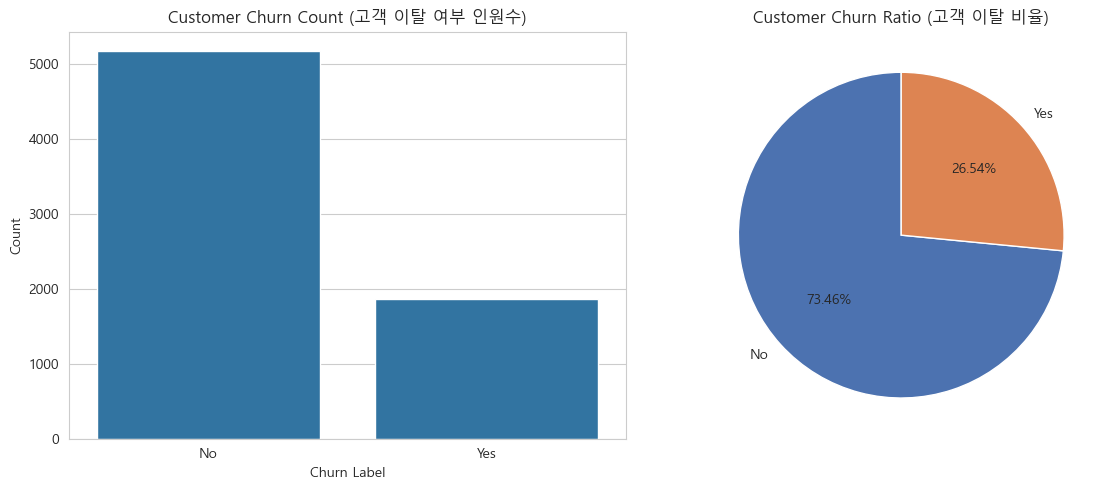

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot: 이탈/잔류 고객 수를 막대그래프로 표현
sns.countplot(x="Churn Label", data=df, ax=axes[0], order=["No", "Yes"])
axes[0].set_title("Customer Churn Count (고객 이탈 여부 인원수)")
axes[0].set_xlabel("Churn Label")
axes[0].set_ylabel("Count")

# Pie Chart: 이탈/잔류 비율을 원형 그래프로 표현
churn_ratio = df["Churn Label"].value_counts()
axes[1].pie(
    churn_ratio,
    labels=churn_ratio.index,
    autopct="%.2f%%",
    startangle=90,
    colors=["#4C72B0", "#DD8452"],
)
axes[1].set_title("Customer Churn Ratio (고객 이탈 비율)")

plt.tight_layout()
plt.show()

## 2-7. 숫자형 변수(Numerical Feature) 분석

각 숫자형 변수에 대해 Histogram(분포), 왜도(Skewness), 첨도(Kurtosis)를 확인합니다.

- **왜도(Skewness)**: 분포가 좌우 대칭인지, 한쪽으로 치우쳐(꼬리가 긴 방향으로) 있는지를
  나타내는 값입니다. 0에 가까울수록 좌우 대칭이고, 양수이면 오른쪽 꼬리가 길고(오른쪽에
  소수의 큰 값), 음수이면 왼쪽 꼬리가 깁니다.
- **첨도(Kurtosis)**: 분포가 얼마나 뾰족한지(중심에 값이 몰려 있는지)를 나타냅니다.
  0에 가까우면 정규분포와 비슷한 뾰족함이고, 음수이면 정규분포보다 완만(납작)합니다.


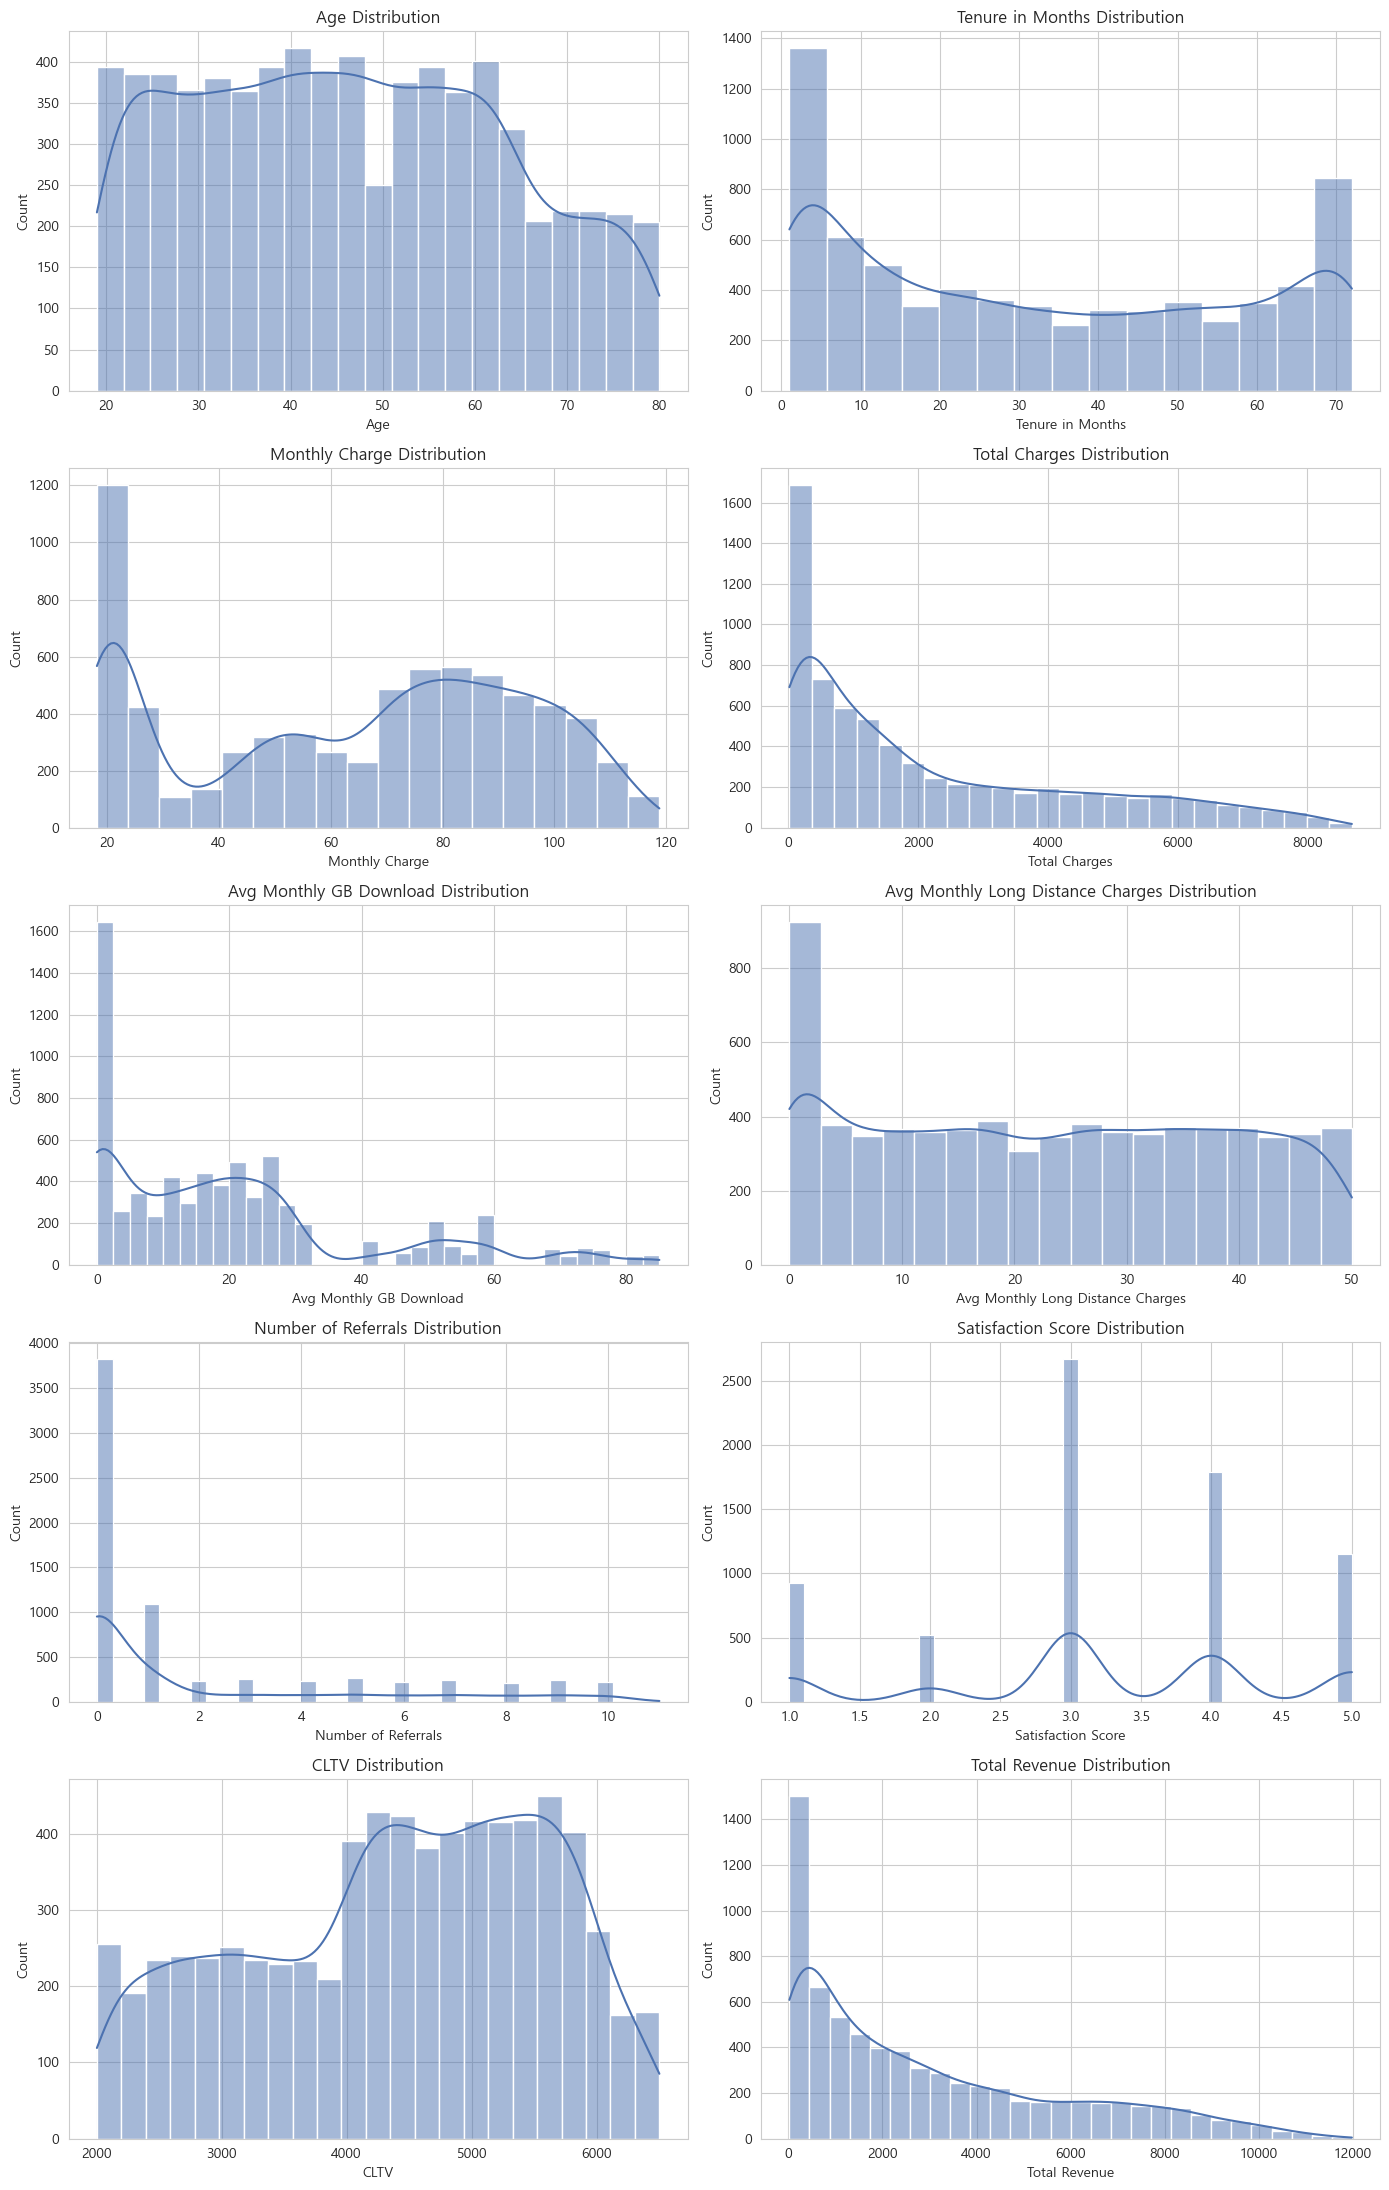

In [157]:
numeric_columns = [
    "Age",
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges",
    "Avg Monthly GB Download",
    "Avg Monthly Long Distance Charges",
    "Number of Referrals",
    "Satisfaction Score",
    "CLTV",
    "Total Revenue",
]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [158]:
# 왜도(Skewness), 첨도(Kurtosis) 요약표
skew_kurt = pd.DataFrame({
    "mean": df[numeric_columns].mean(),
    "std": df[numeric_columns].std(),
    "skew": df[numeric_columns].skew(),
    "kurtosis": df[numeric_columns].kurt(),
}).round(4)

skew_kurt

,mean,std,skew,kurtosis
Age,46.5097,16.7504,0.1622,-1.0028
Tenure in Months,32.3868,24.5421,0.2405,-1.3871
Monthly Charge,64.7617,30.0900,-0.2205,-1.2573
Total Charges,2280.3813,2266.2205,0.9638,-0.2277
Avg Monthly GB Download,20.5154,20.4189,1.2166,0.8815
Avg Monthly Long Distance Charges,22.9590,15.4481,0.0492,-1.2547
Number of Referrals,1.9519,3.0012,1.4461,0.7220
Satisfaction Score,3.2449,1.2017,-0.3674,-0.5369
CLTV,4400.2958,1183.0572,-0.3116,-0.9340
Total Revenue,3034.3791,2865.2045,0.9194,-0.2035


## 2-8. 범주형 변수(Categorical Feature) 분석

각 범주형 변수에 대해 `value_counts()`(값별 개수), Countplot(막대그래프), 그리고
Target(Churn)과의 관계를 함께 확인합니다.


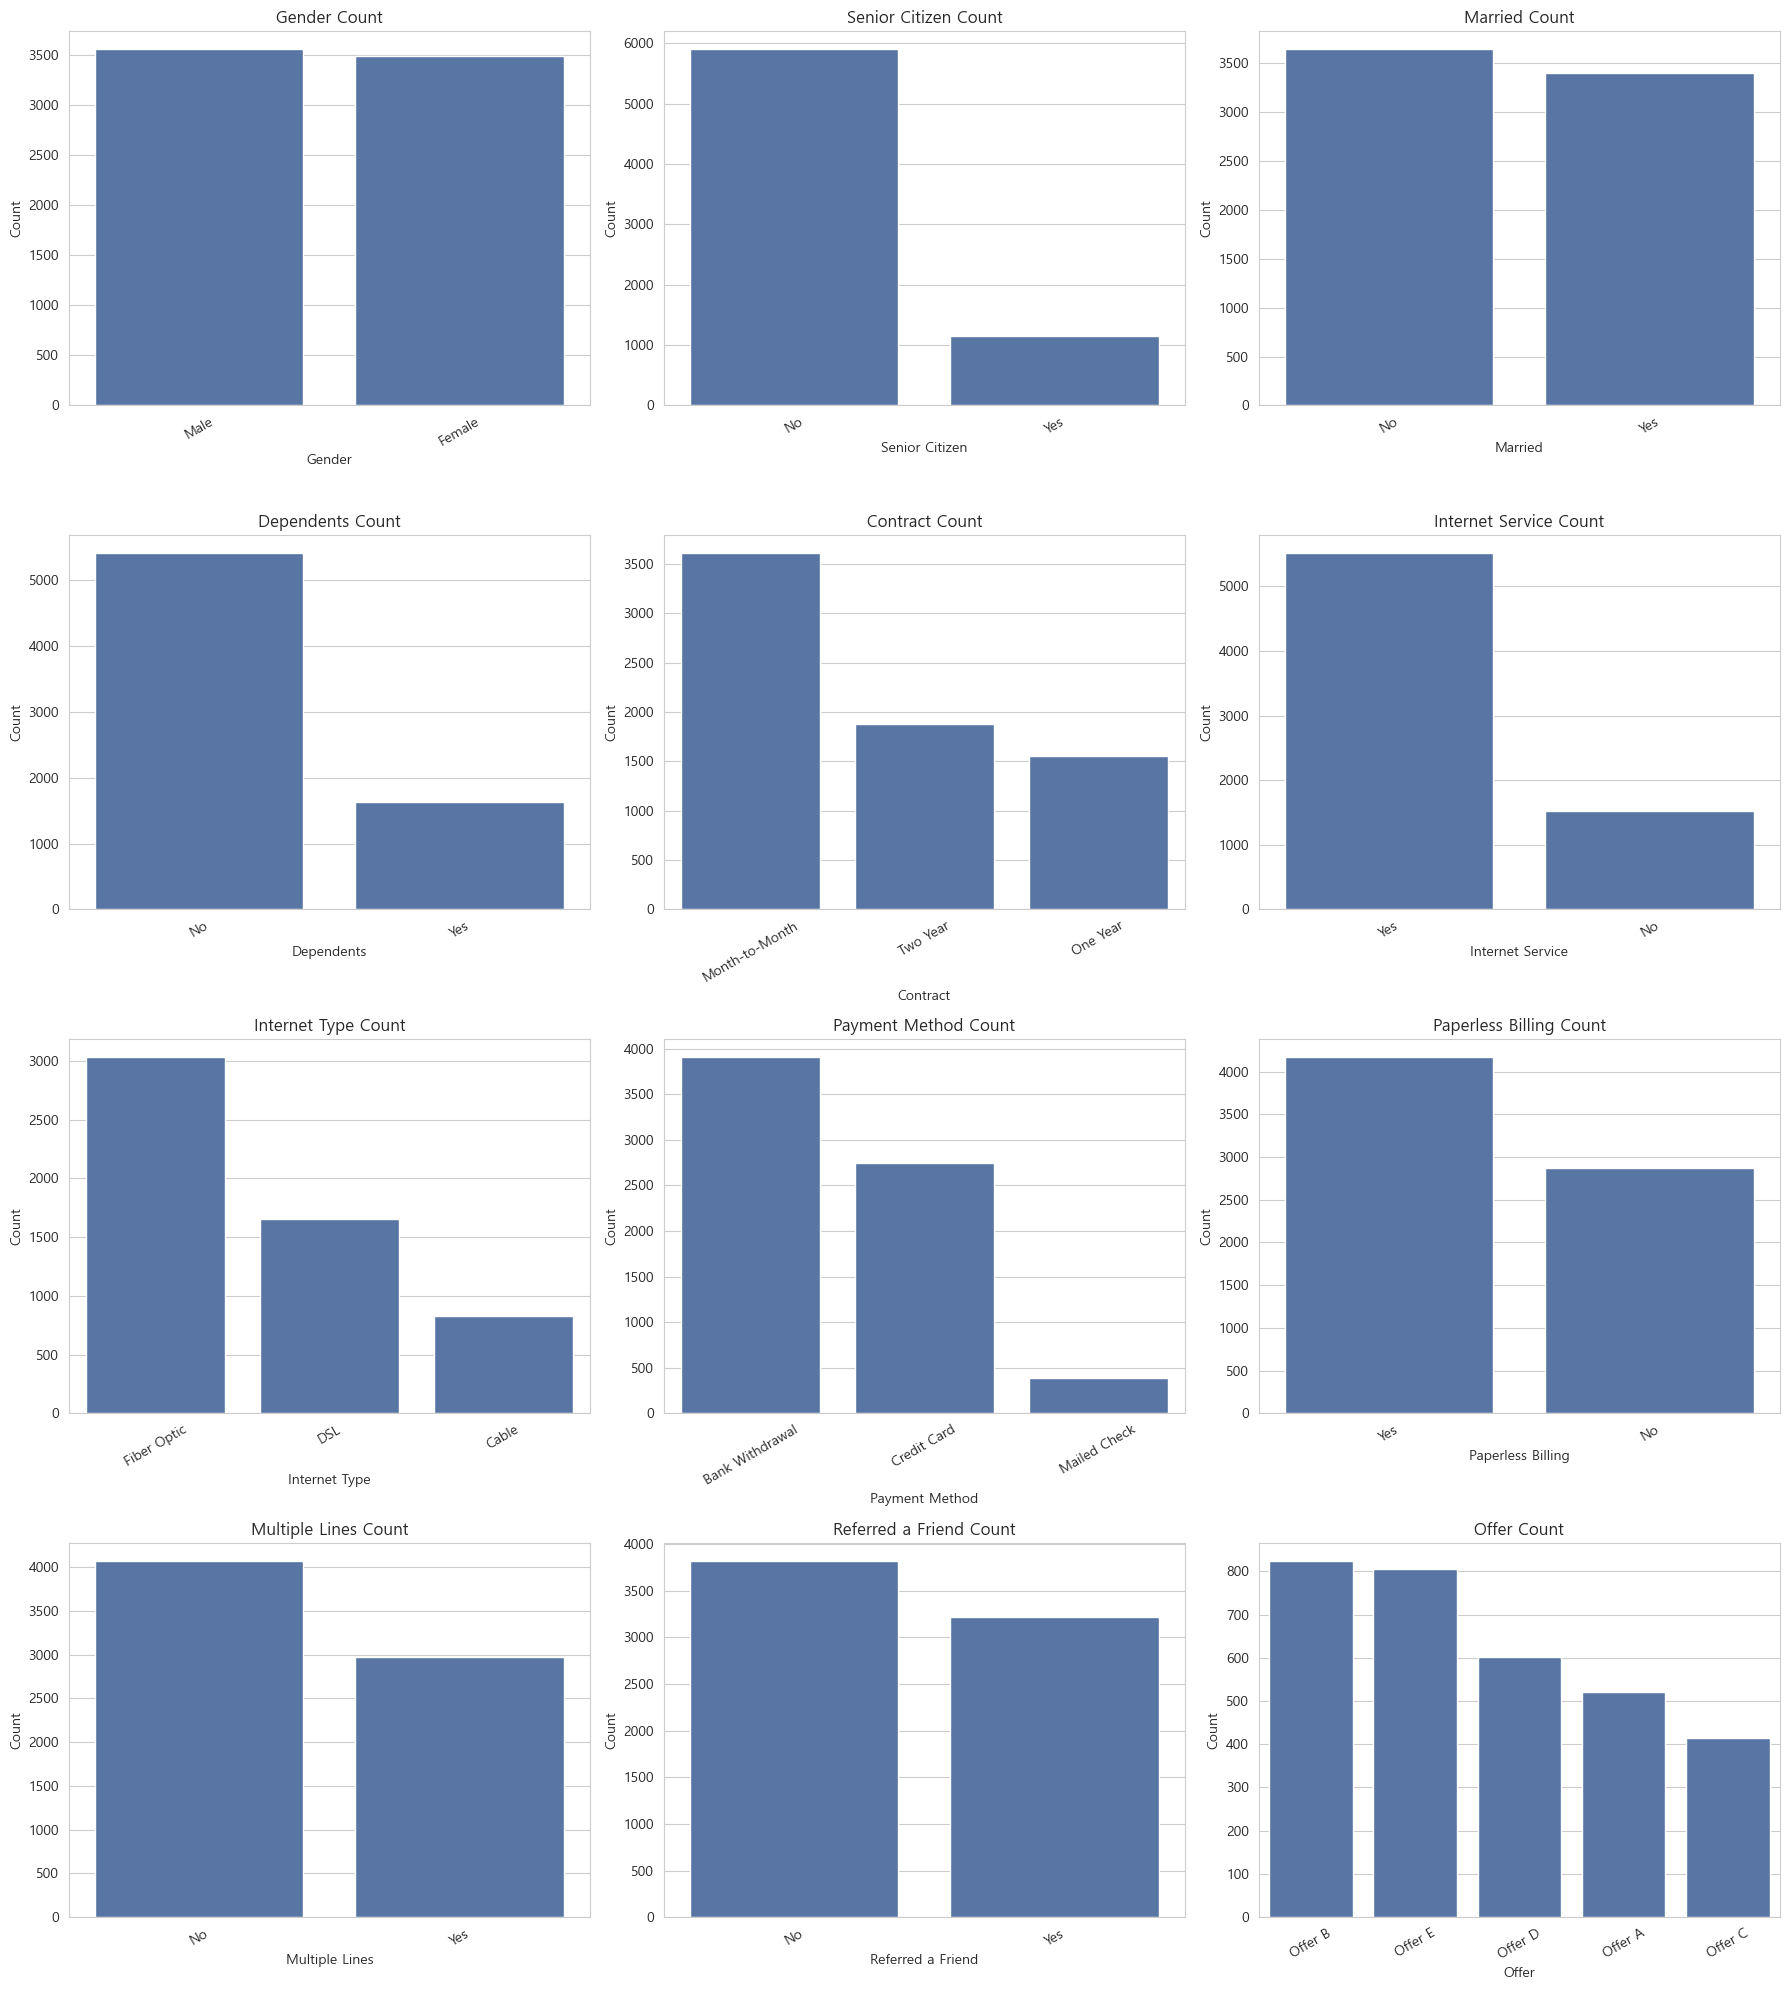

In [159]:
categorical_columns = [
    "Gender",
    "Senior Citizen",
    "Married",
    "Dependents",
    "Contract",
    "Internet Service",
    "Internet Type",
    "Payment Method",
    "Paperless Billing",
    "Multiple Lines",
    "Referred a Friend",
    "Offer",
]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    # value_counts(dropna=False)로 계산한 순서에 NaN이 섞여 있으면 그래프 축(str 전용)에
    # 그릴 수 없으므로, 그래프의 막대 순서는 결측치를 제외한 값으로만 정합니다.
    # (결측치 비율 자체는 2-4에서 이미 별도로 확인했습니다)
    order = df[col].value_counts(dropna=True).index
    sns.countplot(x=col, data=df, order=order, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col} Count")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [160]:
# 범주형 변수별 이탈률(Churn Rate) 요약
for col in categorical_columns:
    print(f"--- {col} 별 이탈률 ---")
    print(df.groupby(col, dropna=False)["Churn"].agg(["mean", "count"]).round(4))
    print()

--- Gender 별 이탈률 ---
          mean  count
Gender               
Female  0.2692   3488
Male    0.2616   3555

--- Senior Citizen 별 이탈률 ---
                  mean  count
Senior Citizen               
No              0.2361   5901
Yes             0.4168   1142

--- Married 별 이탈률 ---
           mean  count
Married               
No       0.3296   3641
Yes      0.1966   3402

--- Dependents 별 이탈률 ---
              mean  count
Dependents               
No          0.3255   5416
Yes         0.0652   1627

--- Contract 별 이탈률 ---
                  mean  count
Contract                     
Month-to-Month  0.4584   3610
One Year        0.1071   1550
Two Year        0.0255   1883

--- Internet Service 별 이탈률 ---
                    mean  count
Internet Service               
No                0.0740   1526
Yes               0.3183   5517

--- Internet Type 별 이탈률 ---
                 mean  count
Internet Type               
Cable          0.2566    830
DSL            0.1858   1652
Fiber Optic    0.

## 2-9. 상관관계(Correlation) 분석

숫자형 변수들 사이의 **피어슨 상관계수(Pearson Correlation Coefficient)** 를 계산합니다.
상관계수는 -1 ~ 1 사이의 값을 가지며,

- **1에 가까울수록** 강한 양의 상관관계 (하나가 커지면 다른 하나도 커짐)
- **-1에 가까울수록** 강한 음의 상관관계 (하나가 커지면 다른 하나는 작아짐)
- **0에 가까울수록** 선형적인 관계가 거의 없음



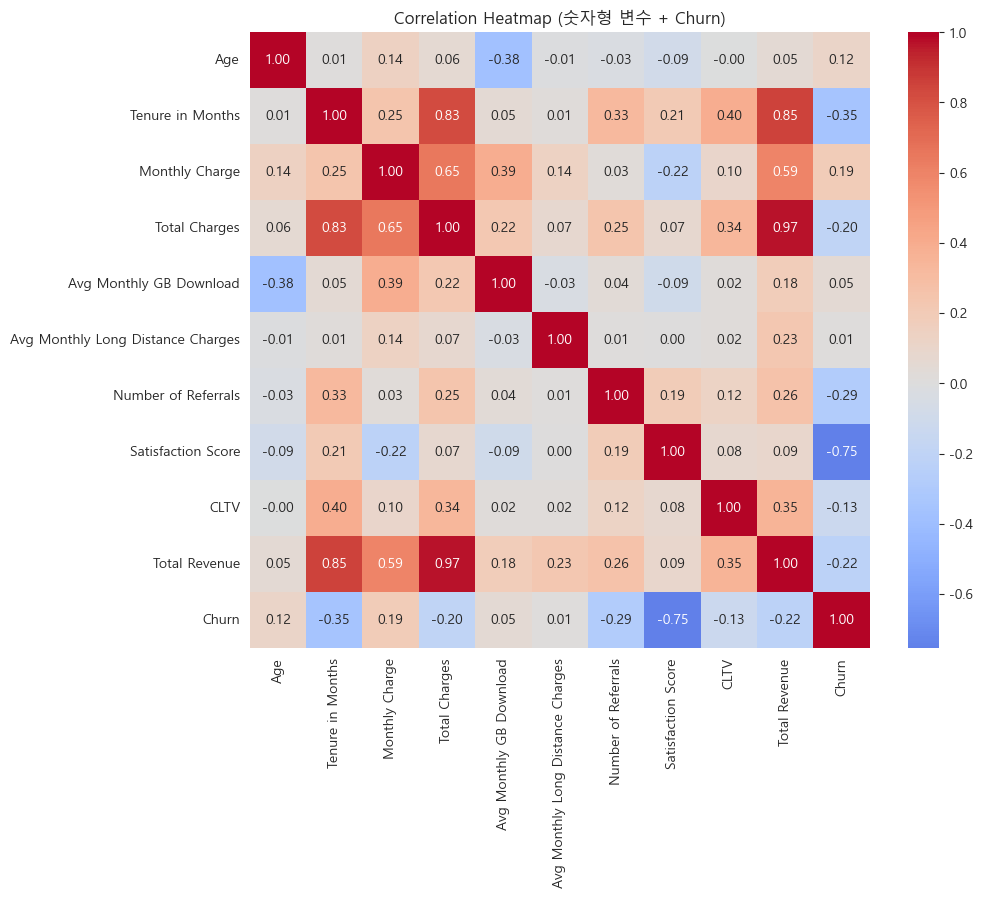

In [161]:
corr_columns = numeric_columns + ["Churn"]
corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (숫자형 변수 + Churn)")
plt.show()


## 2-10. Box Plot - 이상치(Outlier) 분석


Box Plot(상자 그림)은 데이터의 분포를 다음 5가지 값으로 요약해서 보여줍니다.

```text
최솟값(이상치 제외) ─ 1사분위수(Q1) ─ 중앙값(Median) ─ 3사분위수(Q3) ─ 최댓값(이상치 제외)
```

Q1과 Q3 사이의 거리를 **IQR(사분위 범위, Interquartile Range)** 이라고 하며,
일반적으로 `Q1 - 1.5*IQR` 보다 작거나 `Q3 + 1.5*IQR` 보다 큰 값을 통계적 이상치로 봅니다.



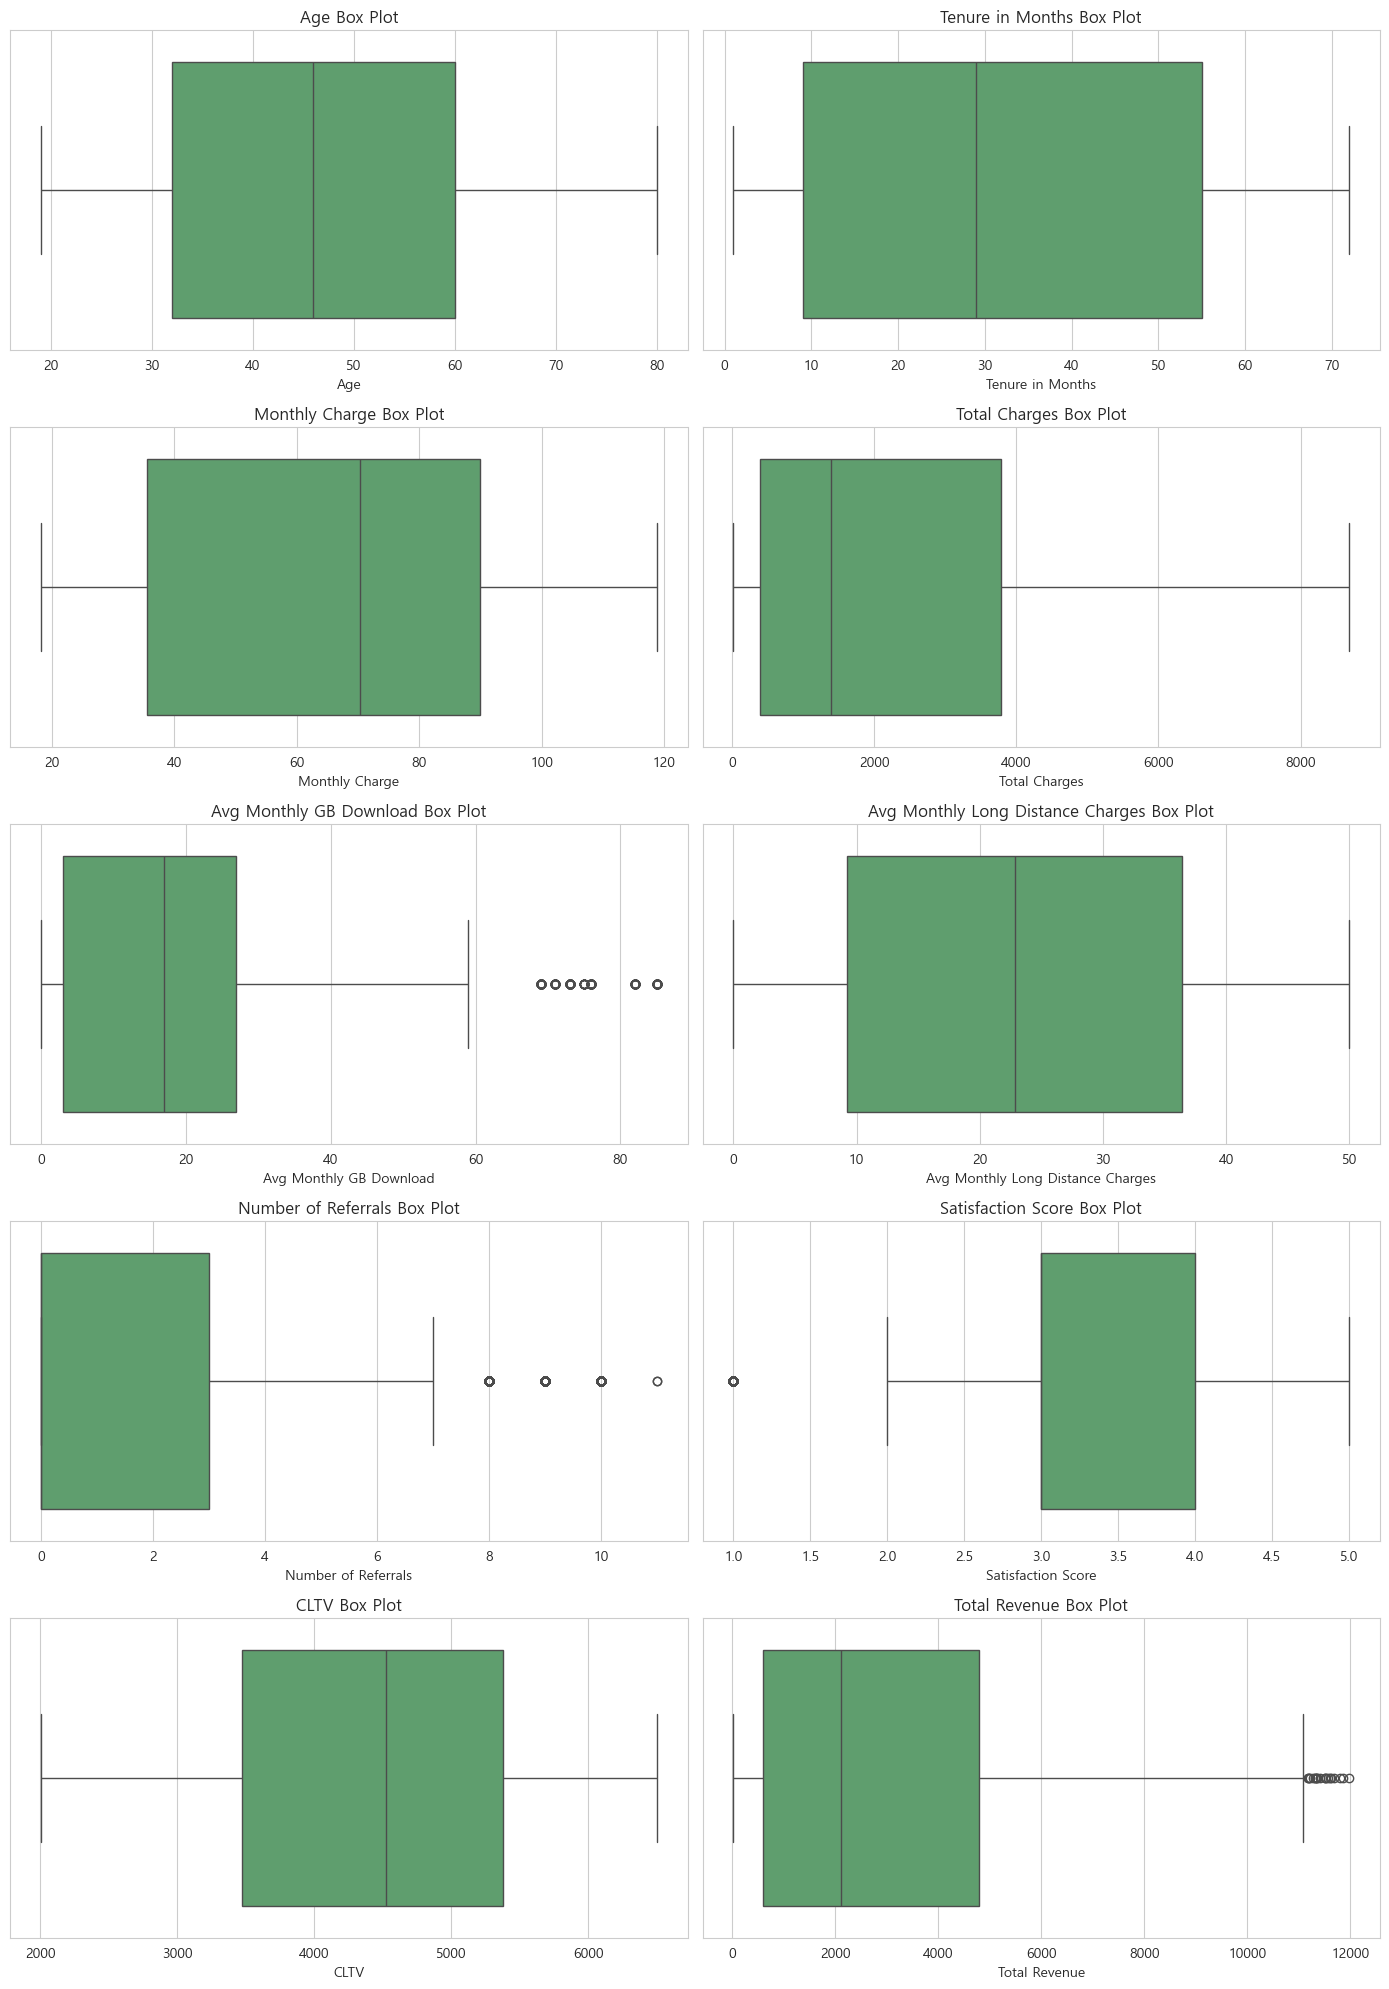

IQR 기준 컬럼별 이상치 개수:
  Age : 0건
  Tenure in Months : 0건
  Monthly Charge : 0건
  Total Charges : 0건
  Avg Monthly GB Download : 362건
  Avg Monthly Long Distance Charges : 0건
  Number of Referrals : 676건
  Satisfaction Score : 922건
  CLTV : 0건
  Total Revenue : 21건


In [162]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

outlier_summary = {}
for i, col in enumerate(numeric_columns):
    sns.boxplot(x=df[col], ax=axes[i], color="#55A868")
    axes[i].set_title(f"{col} Box Plot")
    axes[i].set_xlabel(col)

    # IQR 기준 이상치 개수 계산
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outlier_count

plt.tight_layout()
plt.show()

print("IQR 기준 컬럼별 이상치 개수:")
for col, cnt in outlier_summary.items():
    print(f"  {col} : {cnt}건")

## 2-11. EDA 핵심 발견 사항(EDA Findings)

지금까지의 EDA 결과를 근거와 함께 정리하면 다음과 같습니다. (모든 수치는 위에서 실제로
계산한 결과입니다)

**Finding 1. 계약 기간이 짧을수록 이탈률이 급격히 높아진다.**
근거: Month-to-Month 45.84% vs One Year 10.71% vs Two Year 2.55%
해석: Contract는 이 데이터셋에서 가장 강력한 이탈 예측 신호 중 하나이다.

**Finding 2. 가입 기간(Tenure)이 짧을수록 이탈률이 높다.**
근거: 신규 고객(가입 6개월 이하) 53.33% vs 그 외 19.47%. Tenure와 Churn의 상관계수는 -0.35.
해석: 서비스 초반 6개월이 이탈을 막아야 하는 "골든 타임"이다.

**Finding 3. 인터넷 서비스, 특히 광랜(Fiber Optic) 고객의 이탈률이 유독 높다.**
근거: 인터넷 미가입 7.40% vs 가입 31.83%. Internet Type 중 Fiber Optic 40.72% > Cable 25.66% > DSL 18.58%.
해석: 광랜 서비스의 가격 또는 서비스 품질에 대한 불만족 가능성을 시사한다.

**Finding 4. 온라인 보안/기술지원 서비스를 가입한 고객은 이탈률이 낮다.**
근거: Online Security 미가입 31.33% vs 가입 14.61%. Premium Tech Support 미가입 31.19% vs 가입 15.17%.
두 서비스를 모두 가입한 고객은 9.01%까지 낮아진다(둘 다 미가입은 33.42%).
해석: 부가 서비스 가입은 고객을 "락인(lock-in)"시키는 효과가 있을 수 있다.

**Finding 5. 결제 방식에 따라 이탈률 차이가 크다.**
근거: Mailed Check 36.88% > Bank Withdrawal 34.00% > Credit Card 14.48%
해석: 신용카드 자동 결제 고객이 결제 편의성과 함께 관계 안정성도 높은 경향이 있다.

**Finding 6. 부양가족·배우자가 있는 고객은 이탈률이 낮다.**
근거: Dependents 없음 32.55% vs 있음 6.52%. Married 미혼 32.96% vs 기혼 19.66%.
해석: 가족 단위 고객은 서비스 전환(이사, 재약정 등)에 대한 진입장벽이 더 높을 수 있다.

**Finding 7. 고령 고객(Senior Citizen)의 이탈률이 훨씬 높다.**
근거: 고령자 41.68% vs 비고령자 23.61%.
해석: 다만 고령자이면서 동시에 장기 고객(49개월 이상)인 경우 이탈률이 16.09%로 오히려
평균보다 낮아진다. 즉 "일단 오래 정착한 고령 고객"은 안정적인 반면, 신규로 유입된 고령
고객의 이탈 위험이 특히 높다는 뜻이다. (단순히 "고령자=고위험"이 아니라 가입 기간과의
상호작용을 함께 봐야 한다)

**Finding 8. 부가 서비스 가입 개수와 이탈률은 단순한 선형 관계가 아니다.**
근거: 서비스 0개 43.84%, 1개 19.72%로 오히려 낮아졌다가, 2~5개 구간에서 다시
25~36% 수준으로 올라가고, 8개 이상 가입하면 11.78%까지 낮아진다.
해석: "이것저것 조금씩 가입"한 고객보다 "아예 안 쓰거나 풀옵션으로 다 쓰는" 고객이
극단적인 이탈 패턴을 보인다. 부가 서비스 개수는 구간(Binning)으로 다루거나, 다른
변수와의 조합으로 봐야 의미가 더 명확해질 수 있다.

**Finding 9. 프로모션(Offer) 종류에 따라 이탈률이 극단적으로 다르다.**
근거: Offer E 52.92%, Offer D 26.74%, Offer C 22.89%, Offer B 12.26%, Offer A 6.73%,
프로모션 없음(NaN) 27.11%.
해석: 어떤 프로모션으로 가입했는지가 이후 이탈 여부와 강하게 연관되어 있다. Offer E로
가입한 고객을 대상으로 한 리텐션 전략이 필요해 보인다.

**Finding 10. 만족도 점수(Satisfaction Score)가 가장 강력한 단일 예측 신호이다.**
근거: Churn과의 상관계수 -0.75로 모든 숫자형 변수 중 가장 강하다.
해석: 다만 이 값은 사후적으로 수집된 성격이 강할 수 있으므로, 실제 서비스에 적용할 때는
이 값이 예측 시점에 확보 가능한 정보인지 반드시 확인해야 한다. (Feature Selection 및
서비스 적용 단계에서 다시 논의한다)



# Chapter 3. Hypothesis (가설 수립)

**가설 1.** 계약 기간이 짧을수록(Month-to-Month) 고객은 언제든 위약금 없이 떠날 수 있기
때문에 이탈률이 높을 것이다. → EDA Finding 1에서 확인됨 (45.84% vs 2.55%)

**가설 2.** 가입 초기(6개월 이하) 고객은 아직 서비스에 대한 충성도가 쌓이지 않았고,
신규 고객 대상 경쟁사의 공격적인 프로모션에 노출되기 쉬워 이탈률이 높을 것이다.
→ EDA Finding 2에서 확인됨 (53.33% vs 19.47%)

**가설 3.** 월 요금이 높을수록 고객이 가격에 부담을 느껴 이탈할 가능성이 높을 것이다.
→ Monthly Charge와 Churn의 상관계수 +0.19로 약하지만 존재하는 양의 관계가 확인됨

**가설 4.** 온라인 보안, 기술 지원 같은 부가 서비스에 가입한 고객은 서비스에 더 많이
의존하게 되어(락인 효과) 이탈률이 낮을 것이다. → EDA Finding 4에서 확인됨

**가설 5.** 자동 결제(계좌 이체, 신용카드)를 사용하는 고객은 결제의 번거로움이 적어
서비스를 계속 유지할 가능성이 높을 것이다. → EDA Finding 5에서 확인됨

**가설 6.** 부양가족이나 배우자가 있는 고객은 가족 단위로 서비스를 사용하고 있어
전환 비용(Switching Cost)이 더 크기 때문에 이탈률이 낮을 것이다.
→ EDA Finding 6에서 확인됨

**가설 7.** 계약 기간이 짧으면서 동시에 신규 고객인 경우, 두 위험 요인이 겹쳐서
이탈률이 각각의 개별 효과보다 훨씬 크게 나타날 것이다. → EDA Finding 11에서 확인됨
(57.06% vs 6.31%)

**가설 8.** 월 요금이 높으면서 동시에 월 단위 계약인 고객은 "비싼데 언제든 떠날 수
있는" 상태이므로 이탈 위험이 가장 클 것이다. → Chapter 4에서 직접 검증한다.

**가설 9.** 기술 지원을 받지 못하면서 월 단위 계약인 고객은, 문제가 생겨도 도움을 받지
못한 채 손쉽게 이탈할 수 있어 위험이 클 것이다. → Chapter 4에서 직접 검증한다.

**가설 10.** 부가 서비스 가입 개수가 극단적으로 적거나(0~1개) 많은 경우(8개 이상)
이탈 패턴이 특이하게 나타날 것이므로, 가입 개수를 하나의 파생변수로 만들면 모델이
비선형적인 패턴을 더 쉽게 학습할 수 있을 것이다. → EDA Finding 8에서 확인됨


이제 이 가설들을 실제 파생변수(Feature)로 만드는 **Feature Engineering** 을 시작합니다.


# Chapter 4. Feature Engineering (파생변수 생성)


Feature Engineering은 원본 컬럼을 조합하거나 가공하여, 모델이 패턴을 더 쉽게 학습할 수
있는 새로운 입력값을 만드는 과정입니다. 이번 Chapter에서는 아래 11개의 파생변수를
만듭니다. 각 파생변수는 Chapter 2(EDA)와 Chapter 3(가설)에서 확인한 근거를 바탕으로
설계되었습니다.

```text
1. TenureGroup          - 가입 기간 구간화
2. TotalServices        - 부가 서비스 총 가입 개수
3. StreamingCount       - 스트리밍 서비스 가입 개수
4. InternetCount        - 인터넷 부가 서비스 가입 개수
5. AverageCharge        - 가입 기간 대비 평균 요금
6. HighChargeCustomer   - 고요금 고객 여부
7. ContractRisk         - 계약 + 가입 기간 위험 점수
8. SeniorLongTerm       - 고령 + 장기 고객 여부
9. FamilyCustomer       - 가족 고객 여부
10. CustomerValueTier   - CLTV 기반 고객 가치 등급
11. HighRiskCustomer    - 다중 위험 조건 결합 Feature
```

파생변수를 만들 때는 다음 원칙을 지킵니다.

```text
1. 비즈니스 의미가 있어야 한다.
2. 원본 변수보다 이해하기 쉬운 정보를 제공해야 한다.
3. 예측 시점(고객이 가입/이용 중인 시점)에 계산할 수 있어야 한다.
4. Target(Churn Label)을 직접 사용하지 않는다.
5. 데이터 누수(Data Leakage)가 없어야 한다.
```

## 성능 비교를 위한 준비

각 Feature를 만들 때마다 "이 Feature를 추가하기 전 vs 추가한 후" 모델 성능을 비교합니다.



In [163]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

RANDOM_STATE = 42

# Target, 식별자, 데이터 누수 컬럼은 Feature 실험에서 제외합니다.
LEAKAGE_OR_ID_COLUMNS = [
    "Customer ID", "Customer Status", "Churn Score",
    "Churn Category", "Churn Reason", "Churn Label", "Churn",
]

# 상수 컬럼(Country, State, Quarter)과 과도하게 세분화된 위치 정보(City, Zip, 위경도)는
# Baseline에서 제외합니다. (2-3에서 확인한 것처럼 정보량이 없거나 범주가 너무 많습니다)
LOCATION_OR_CONSTANT_COLUMNS = ["Country", "State", "Quarter", "City", "Zip Code", "Latitude", "Longitude"]

BASELINE_COLUMNS = [
    c for c in df.columns
    if c not in LEAKAGE_OR_ID_COLUMNS + LOCATION_OR_CONSTANT_COLUMNS
]

print(f"Baseline Feature 개수: {len(BASELINE_COLUMNS)}")
print(BASELINE_COLUMNS)


def quick_evaluate(frame, feature_cols, label):
    """주어진 Feature 목록으로 RandomForest를 빠르게 학습하고 성능을 반환한다.
    (Feature Engineering 실습용 - Chapter 6의 공식 Pipeline과는 별개)
    """
    X = pd.get_dummies(frame[feature_cols], drop_first=False)
    y = frame["Churn"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    return {
        "Model": label,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Recall": round(recall_score(y_test, pred), 4),
        "F1": round(f1_score(y_test, pred), 4),
    }


baseline_result = quick_evaluate(df, BASELINE_COLUMNS, "Baseline (원본 Feature)")
feature_experiment_results = [baseline_result]
pd.DataFrame(feature_experiment_results)

Baseline Feature 개수: 37
['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Population', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'CLTV']


,Model,Accuracy,Recall,F1
0,Baseline (원본 Feature),0.9588,0.8663,0.9178


## Feature 1. TenureGroup (가입 기간 구간화)

`Tenure in Months`는 1~72 사이의 연속된 숫자입니다. 하지만 EDA(2-7, Finding 2)에서
확인했듯, 이탈률은 "숫자가 커질수록 일정하게 줄어드는" 단순한 선형 관계가 아니라
0~6개월 구간에서 급격히 높고 그 이후 완만하게 낮아지는 패턴을 보입니다. 이런 "구간별
차이"는 트리 기반 모델은 스스로 어느 정도 찾아낼 수 있지만, Logistic Regression처럼
선형 관계를 가정하는 모델에게는 구간 정보를 직접 알려주는 것이 더 도움이 됩니다.

### 생성 이유
가입 기간을 5개 구간(0-6, 7-12, 13-24, 25-48, 49+ 개월)으로 나누어, "생애 주기 단계"
정보를 범주형 변수로 명확하게 표현합니다.


In [164]:
# 가입 기간을 5개 구간으로 나눕니다.
tenure_bins = [0, 6, 12, 24, 48, 72]
tenure_labels = ["0-6", "7-12", "13-24", "25-48", "49+"]

df["TenureGroup"] = pd.cut(
    df["Tenure in Months"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True,
)

# 구간별 이탈률 확인
tenure_group_churn = df.groupby("TenureGroup", observed=True)["Churn"].agg(["mean", "count"]).round(4)
tenure_group_churn

,mean,count
TenureGroup,,
0-6,0.5333,1470
7-12,0.3534,716
13-24,0.2871,1024
25-48,0.2039,1594
49+,0.0951,2239


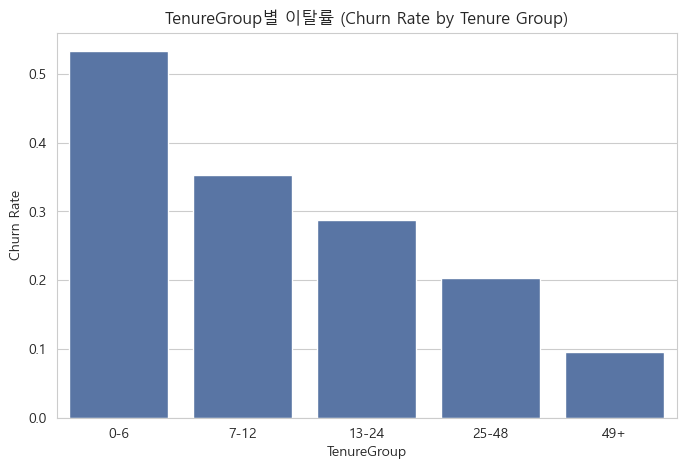

In [165]:
plt.figure(figsize=(8, 5))
sns.barplot(x=tenure_group_churn.index, y=tenure_group_churn["mean"], color="#4C72B0")
plt.title("TenureGroup별 이탈률 (Churn Rate by Tenure Group)")
plt.xlabel("TenureGroup")
plt.ylabel("Churn Rate")
plt.show()

In [166]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["TenureGroup"], "Baseline + TenureGroup")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)

,Model,Accuracy,Recall,F1
0,Baseline (원본 Feature),0.9588,0.8663,0.9178
1,Baseline + TenureGroup,0.9588,0.8690,0.9181


## Feature 2. TotalServices (부가 서비스 총 가입 개수)

이 데이터셋에는 9개의 서비스 가입 여부 컬럼(Phone Service, Multiple Lines, Online
Security, Online Backup, Device Protection Plan, Premium Tech Support, Streaming TV,
Streaming Movies, Streaming Music)이 각각 별도 컬럼으로 존재합니다. 이를 각각 따로
보는 대신, "총 몇 개의 서비스에 가입했는가"라는 하나의 숫자로 요약하면 고객의
전반적인 서비스 이용 강도를 파악할 수 있습니다. 여러 개의 Yes/No 컬럼을 하나의 숫자형 Feature로 요약하는 방법을 익혀봅니다.

### 생성 이유
Finding 8에서 확인했듯, 서비스 가입 개수와 이탈률은 단순하지 않은(비선형) 관계를
보였습니다. 이 관계를 모델이 직접 학습할 수 있도록 하나의 변수로 제공합니다. 



In [167]:
SERVICE_COLUMNS = [
    "Phone Service", "Multiple Lines", "Online Security", "Online Backup",
    "Device Protection Plan", "Premium Tech Support",
    "Streaming TV", "Streaming Movies", "Streaming Music",
]

# 각 서비스 컬럼이 "Yes"인 개수를 세어 총 가입 서비스 개수를 계산합니다.
df["TotalServices"] = (df[SERVICE_COLUMNS] == "Yes").sum(axis=1)

total_services_churn = df.groupby("TotalServices")["Churn"].agg(["mean", "count"]).round(4)
total_services_churn

,mean,count
TotalServices,,
0,0.4384,73
1,0.1972,1668
2,0.3145,1081
3,0.3588,811
4,0.3473,786
5,0.3126,787
6,0.2507,746
7,0.2168,558
8,0.1178,348


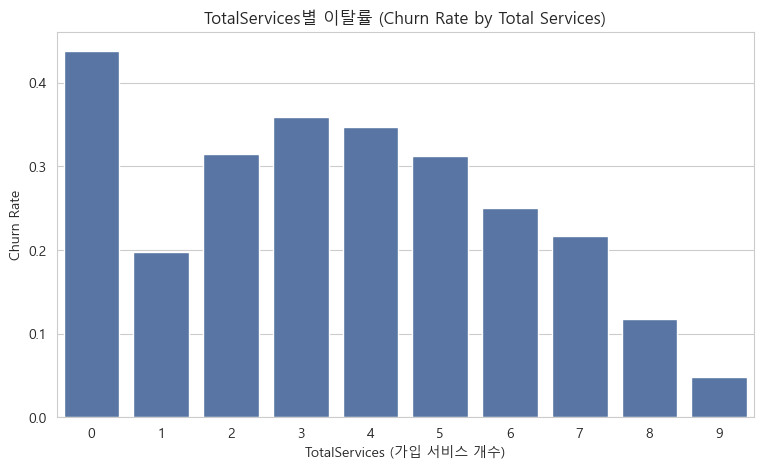

In [168]:
plt.figure(figsize=(9, 5))
sns.barplot(x=total_services_churn.index, y=total_services_churn["mean"], color="#4C72B0")
plt.title("TotalServices별 이탈률 (Churn Rate by Total Services)")
plt.xlabel("TotalServices (가입 서비스 개수)")
plt.ylabel("Churn Rate")
plt.show()

In [169]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["TotalServices"], "Baseline + TotalServices")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)

,Model,Accuracy,Recall,F1
0,Baseline (원본 Feature),0.9588,0.8663,0.9178
1,Baseline + TenureGroup,0.9588,0.8690,0.9181
2,Baseline + TotalServices,0.9624,0.8797,0.9255


## Feature 3. StreamingCount / Feature 4. InternetCount

TotalServices는 모든 서비스를 하나로 합쳤지만, 서비스는 성격이 다른 두 그룹으로 나눌 수
있습니다.

- **엔터테인먼트 그룹**: Streaming TV, Streaming Movies, Streaming Music (최대 3개)
- **인터넷 보안/지원 그룹**: Online Security, Online Backup, Device Protection Plan,
  Premium Tech Support (최대 4개)

### 생성 이유
Finding 4에서 확인했듯 보안/지원 서비스는 이탈을 낮추는 효과가 뚜렷했습니다. 이 효과가
TotalServices에 섞여서 희석되지 않도록, 성격이 다른 두 그룹을 별도 변수로 분리합니다.


In [170]:
STREAMING_COLUMNS = ["Streaming TV", "Streaming Movies", "Streaming Music"]
INTERNET_ADDON_COLUMNS = ["Online Security", "Online Backup", "Device Protection Plan", "Premium Tech Support"]

df["StreamingCount"] = (df[STREAMING_COLUMNS] == "Yes").sum(axis=1)
df["InternetCount"] = (df[INTERNET_ADDON_COLUMNS] == "Yes").sum(axis=1)

print("StreamingCount별 이탈률:")
print(df.groupby("StreamingCount")["Churn"].agg(["mean", "count"]).round(4))

print("\nInternetCount별 이탈률:")
print(df.groupby("InternetCount")["Churn"].agg(["mean", "count"]).round(4))

StreamingCount별 이탈률:
                  mean  count
StreamingCount               
0               0.2160   3445
1               0.3621    939
2               0.3387    989
3               0.2695   1670

InternetCount별 이탈률:
                 mean  count
InternetCount               
0              0.2975   2793
1              0.3885   1467
2              0.2376   1372
3              0.1243    941
4              0.0532    470


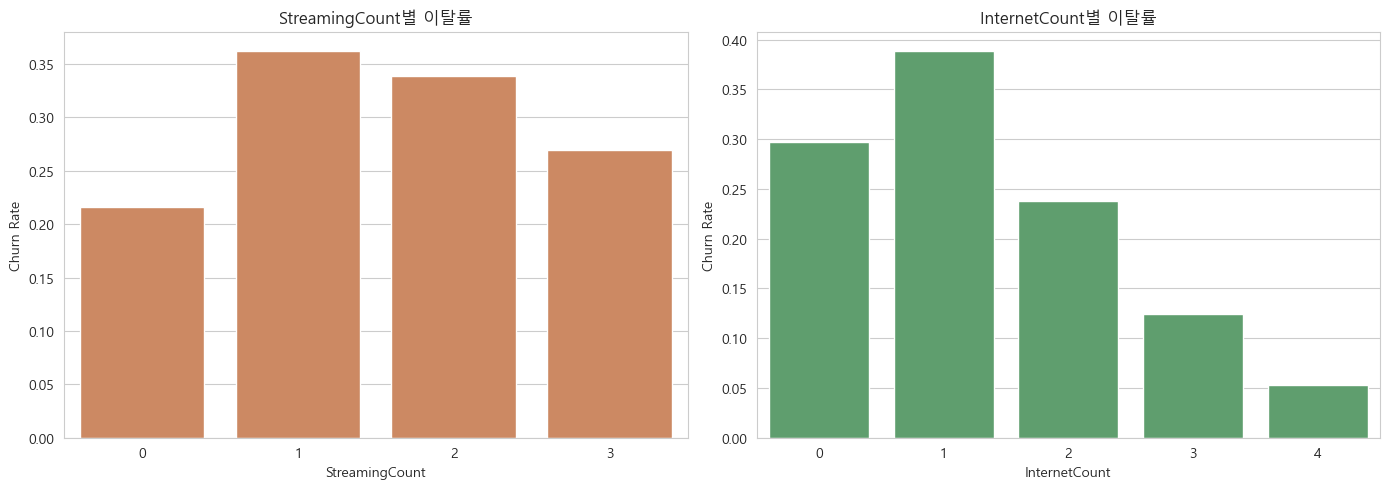

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

streaming_churn = df.groupby("StreamingCount")["Churn"].mean()
internet_churn = df.groupby("InternetCount")["Churn"].mean()

sns.barplot(x=streaming_churn.index, y=streaming_churn.values, ax=axes[0], color="#DD8452")
axes[0].set_title("StreamingCount별 이탈률")
axes[0].set_xlabel("StreamingCount")
axes[0].set_ylabel("Churn Rate")

sns.barplot(x=internet_churn.index, y=internet_churn.values, ax=axes[1], color="#55A868")
axes[1].set_title("InternetCount별 이탈률")
axes[1].set_xlabel("InternetCount")
axes[1].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()

In [172]:
result = quick_evaluate(
    df, BASELINE_COLUMNS + ["TotalServices", "StreamingCount", "InternetCount"],
    "Baseline + TotalServices + StreamingCount + InternetCount",
)
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)

,Model,Accuracy,Recall,F1
0,Baseline (원본 Feature),0.9588,0.8663,0.9178
1,Baseline + TenureGroup,0.9588,0.8690,0.9181
2,Baseline + TotalServices,0.9624,0.8797,0.9255
3,Baseline + TotalServices + StreamingCount + In...,0.9595,0.8690,0.9194


## Feature 5. AverageCharge (가입 기간 대비 평균 요금)

두 컬럼을 나누어 새로운 비율(Ratio) Feature를 만드는 방법과, 0으로 나누는 문제를
안전하게 처리하는 방법을 익힌다.

### 이론
`Total Charges`(총 요금)를 `Tenure in Months`(가입 기간)로 나누면 "평균적으로 매달
얼마를 냈는가"를 계산할 수 있습니다. 이는 프로모션 할인, 요금제 변경 이력 등이 반영된
"실질 평균 요금"이라는 점에서 `Monthly Charge`(현재 시점의 월 요금)와는 다른 정보를
담을 수 있습니다.

### 생성 이유
가입 기간 동안 요금이 바뀌었을 수 있는 고객을 구분해내기 위해 만듭니다.


In [173]:
# 0으로 나누는 문제를 방지하기 위해 Tenure in Months가 0인 경우를 NaN으로 바꾼 뒤
# 나누고, 다시 Monthly Charge로 채웁니다. (이 데이터셋은 최소 가입 기간이 1개월이라
# 실제로 0으로 나뉘는 경우는 없지만, 안전한 코드 작성 습관을 위해 처리합니다)
df["AverageCharge"] = (
    df["Total Charges"] / df["Tenure in Months"].replace(0, np.nan)
).fillna(df["Monthly Charge"])

print("AverageCharge와 Monthly Charge의 상관계수:", round(df["AverageCharge"].corr(df["Monthly Charge"]), 4))
df[["Monthly Charge", "AverageCharge"]].describe().round(2)

AverageCharge와 Monthly Charge의 상관계수: 0.9962


,Monthly Charge,AverageCharge
count,7043.00,7043.00
mean,64.76,64.76
std,30.09,30.19
min,18.25,13.78
25%,35.50,35.94
50%,70.35,70.34
75%,89.85,90.17
max,118.75,121.40


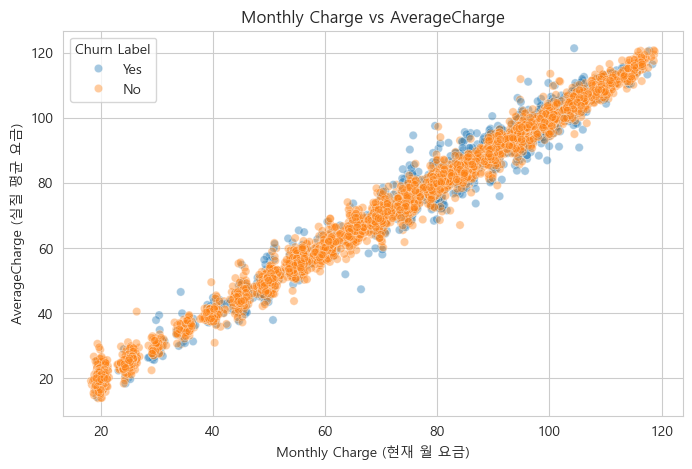

In [174]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Monthly Charge", y="AverageCharge", hue="Churn Label", data=df, alpha=0.4)
plt.title("Monthly Charge vs AverageCharge")
plt.xlabel("Monthly Charge (현재 월 요금)")
plt.ylabel("AverageCharge (실질 평균 요금)")
plt.show()

## Feature 6. HighChargeCustomer (고요금 고객 여부)

연속형 변수를 특정 기준(threshold)으로 이진화(Binarization)하는 방법과, 왜 반드시
"학습 데이터" 기준으로 기준값을 정해야 하는지 이해한다.

### 이론
가설 3(월 요금이 높을수록 이탈 확률이 높다)을 더 명확한 신호로 만들기 위해, 월 요금이
상위 25%(3사분위수)보다 높은 고객을 "고요금 고객"으로 표시합니다.

### 생성 이유
Monthly Charge를 연속값 그대로 두는 것보다, "비싸다/비싸지 않다"라는 이진 신호로 만들면
Logistic Regression 같은 모델이 임계값 효과를 더 쉽게 학습할 수 있습니다.


In [175]:
# 탐색 단계에서는 전체 데이터의 3사분위수를 사용합니다.
# (Chapter 6 이후 공식 Pipeline에서는 Train 데이터 기준으로 다시 계산합니다)
high_charge_threshold = df["Monthly Charge"].quantile(0.75)
print("Monthly Charge 상위 25% 기준값:", round(high_charge_threshold, 2))

df["HighChargeCustomer"] = (df["Monthly Charge"] > high_charge_threshold).astype(int)

high_charge_churn = df.groupby("HighChargeCustomer")["Churn"].agg(["mean", "count"]).round(4)
high_charge_churn

Monthly Charge 상위 25% 기준값: 89.85


,mean,count
HighChargeCustomer,,
0,0.2443,5285
1,0.3288,1758


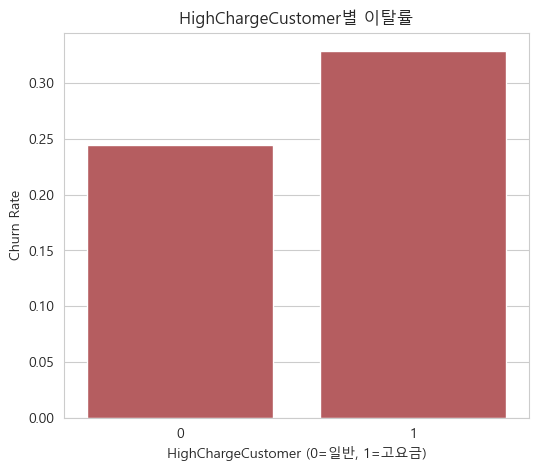

In [176]:
plt.figure(figsize=(6, 5))
sns.barplot(x=high_charge_churn.index, y=high_charge_churn["mean"], color="#C44E52")
plt.title("HighChargeCustomer별 이탈률")
plt.xlabel("HighChargeCustomer (0=일반, 1=고요금)")
plt.ylabel("Churn Rate")
plt.show()

In [177]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["HighChargeCustomer"], "Baseline + HighChargeCustomer")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)

,Model,Accuracy,Recall,F1
0,Baseline (원본 Feature),0.9588,0.8663,0.9178
1,Baseline + TenureGroup,0.9588,0.8690,0.9181
2,Baseline + TotalServices,0.9624,0.8797,0.9255
3,Baseline + TotalServices + StreamingCount + In...,0.9595,0.8690,0.9194
4,Baseline + HighChargeCustomer,0.9603,0.8770,0.9213


## Feature 7. ContractRisk (계약 + 가입 기간 위험 점수)

여러 위험 신호를 하나의 "점수(Score)"로 합치는 상호작용(Interaction) Feature를 설계할
수 있다.

### 이론
가설 7에서 확인했듯, Month-to-Month 계약과 신규 고객(6개월 이하)이라는 두 조건이
동시에 만족될 때 이탈률이 각각의 개별 효과를 합친 것보다 훨씬 크게 나타났습니다.
(Finding 11: 57.06% vs 6.31%). 두 조건을 개별 컬럼으로 각각 넣는 것보다, "위험 요인이
몇 개나 겹치는가"를 하나의 점수로 표현하면 모델이 상호작용을 더 쉽게 학습할 수 있습니다.

### 생성 이유
Month-to-Month 계약 여부(0/1)와 신규 고객 여부(0/1)를 더해서 0~2점 사이의 위험 점수를
만듭니다.


In [178]:
df["IsMonthToMonth"] = (df["Contract"] == "Month-to-Month").astype(int)
df["IsNewCustomer"] = (df["Tenure in Months"] <= 6).astype(int)

df["ContractRisk"] = df["IsMonthToMonth"] + df["IsNewCustomer"]

contract_risk_churn = df.groupby("ContractRisk")["Churn"].agg(["mean", "count"]).round(4)
contract_risk_churn

,mean,count
ContractRisk,,
0,0.0631,3330
1,0.3747,2346
2,0.5706,1367


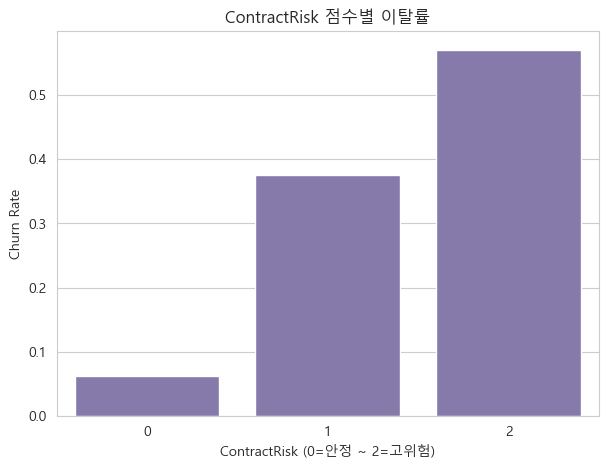

In [179]:
plt.figure(figsize=(7, 5))
sns.barplot(x=contract_risk_churn.index, y=contract_risk_churn["mean"], color="#8172B2")
plt.title("ContractRisk 점수별 이탈률")
plt.xlabel("ContractRisk (0=안정 ~ 2=고위험)")
plt.ylabel("Churn Rate")
plt.show()

In [180]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["ContractRisk"], "Baseline + ContractRisk")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)

,Model,Accuracy,Recall,F1
0,Baseline (원본 Feature),0.9588,0.8663,0.9178
1,Baseline + TenureGroup,0.9588,0.8690,0.9181
2,Baseline + TotalServices,0.9624,0.8797,0.9255
3,Baseline + TotalServices + StreamingCount + In...,0.9595,0.8690,0.9194
4,Baseline + HighChargeCustomer,0.9603,0.8770,0.9213
5,Baseline + ContractRisk,0.9624,0.8770,0.9252


## Feature 8. SeniorLongTerm (고령 + 장기 고객 여부)

"주 효과(Main Effect)"와 "상호작용 효과(Interaction Effect)"가 다를 수 있다는 것을
직접 확인한다.

### 이론
Finding 7에서 고령 고객(Senior Citizen)의 이탈률이 41.68%로 매우 높다고 확인했습니다.
그런데 "고령이면서 동시에 가입 기간이 49개월 이상인 장기 고객"만 따로 떼어보면
어떨까요? 이 질문에 답하기 위한 Feature입니다.

### 생성 이유
"고령자는 무조건 위험하다"는 단순한 결론이 실제로도 맞는지, 가입 기간이라는 다른
변수와 결합했을 때도 유지되는지 검증하기 위해 만듭니다.


In [181]:
df["IsLongTermCustomer"] = (df["Tenure in Months"] >= 49).astype(int)
df["SeniorLongTerm"] = ((df["Senior Citizen"] == "Yes") & (df["IsLongTermCustomer"] == 1)).astype(int)

print("고령 고객 전체 이탈률:", round(df[df['Senior Citizen'] == 'Yes']['Churn'].mean(), 4))
print()
print("SeniorLongTerm 여부별 이탈률:")
print(df.groupby("SeniorLongTerm")["Churn"].agg(["mean", "count"]).round(4))

고령 고객 전체 이탈률: 0.4168

SeniorLongTerm 여부별 이탈률:
                  mean  count
SeniorLongTerm               
0               0.2712   6670
1               0.1609    373


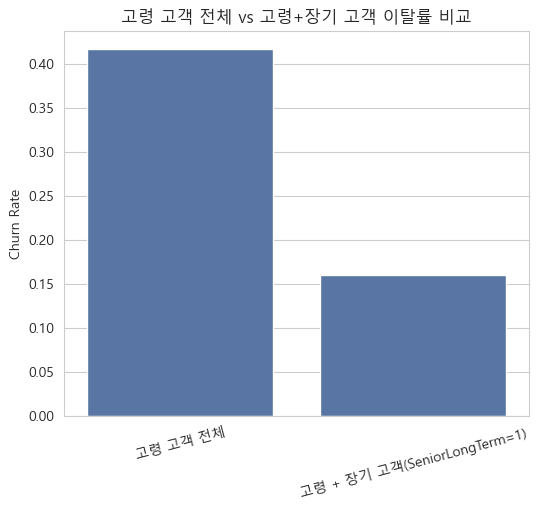

In [182]:
compare = pd.DataFrame({
    "Group": ["고령 고객 전체", "고령 + 장기 고객(SeniorLongTerm=1)"],
    "ChurnRate": [
        df[df["Senior Citizen"] == "Yes"]["Churn"].mean(),
        df[df["SeniorLongTerm"] == 1]["Churn"].mean(),
    ],
}).round(4)

plt.figure(figsize=(6, 5))
sns.barplot(x="Group", y="ChurnRate", data=compare, color="#4C72B0")
plt.title("고령 고객 전체 vs 고령+장기 고객 이탈률 비교")
plt.xlabel("")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15)
plt.show()

## Feature 9. FamilyCustomer (가족 고객 여부)

OR 조건을 사용한 파생변수 생성 방법을 익힌다.

### 이론
가설 6에서 배우자(Married) 또는 부양가족(Dependents)이 있는 고객이 더 안정적이라고
확인했습니다. 두 조건 중 하나라도 해당되면 "가족 단위 고객"으로 볼 수 있습니다.

### 생성 이유
Married와 Dependents를 각각 보는 대신, "가족과 관련된 책임이 있는가"라는 하나의
질문으로 통합합니다.


In [183]:
df["FamilyCustomer"] = ((df["Married"] == "Yes") | (df["Dependents"] == "Yes")).astype(int)

family_churn = df.groupby("FamilyCustomer")["Churn"].agg(["mean", "count"]).round(4)
family_churn

,mean,count
FamilyCustomer,,
0,0.3444,3339
1,0.1941,3704


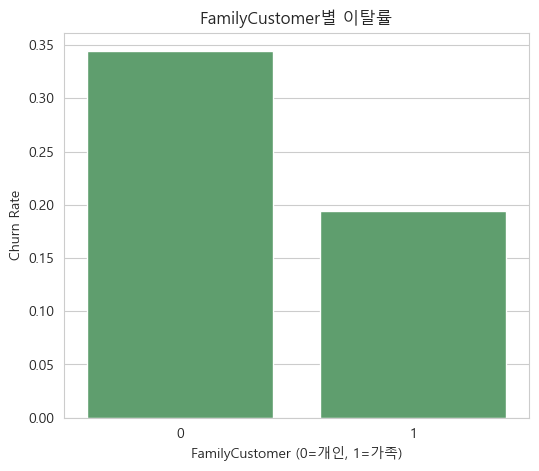

In [184]:
plt.figure(figsize=(6, 5))
sns.barplot(x=family_churn.index, y=family_churn["mean"], color="#55A868")
plt.title("FamilyCustomer별 이탈률")
plt.xlabel("FamilyCustomer (0=개인, 1=가족)")
plt.ylabel("Churn Rate")
plt.show()

In [185]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["FamilyCustomer"], "Baseline + FamilyCustomer")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)

,Model,Accuracy,Recall,F1
0,Baseline (원본 Feature),0.9588,0.8663,0.9178
1,Baseline + TenureGroup,0.9588,0.8690,0.9181
2,Baseline + TotalServices,0.9624,0.8797,0.9255
3,Baseline + TotalServices + StreamingCount + In...,0.9595,0.8690,0.9194
4,Baseline + HighChargeCustomer,0.9603,0.8770,0.9213
5,Baseline + ContractRisk,0.9624,0.8770,0.9252
6,Baseline + FamilyCustomer,0.9581,0.8636,0.9163


## Feature 10. CustomerValueTier (CLTV 기반 고객 가치 등급)

연속형 변수를 `qcut`(분위수 기준)으로 구간화하는 방법을 익힌다. `cut`(값 기준)과의
차이를 이해한다.

### 이론
`CLTV`(Customer Lifetime Value, 고객 생애 가치)는 이 고객이 장기적으로 회사에
가져다줄 것으로 예상되는 가치를 나타내는 지표입니다. 값의 범위가 넓고 분포가
고르지 않을 수 있으므로, 특정 값 기준(`cut`)이 아니라 **데이터 개수가 균등하게 나뉘는
분위수 기준(`qcut`)** 으로 3등급(Low, Medium, High)을 나눕니다.

### 생성 이유
가설 11(CLTV가 낮은 고객군의 이탈률이 더 높을 것이다)을 직접 검증하기 위해 만듭니다.


In [186]:
# qcut: 데이터 개수가 균등하게 3구간으로 나뉘도록 분위수 기준으로 나눕니다.
df["CustomerValueTier"] = pd.qcut(df["CLTV"], q=3, labels=["Low", "Medium", "High"])

value_tier_churn = df.groupby("CustomerValueTier", observed=True)["Churn"].agg(["mean", "count"]).round(4)
value_tier_churn

,mean,count
CustomerValueTier,,
Low,0.3437,2348
Medium,0.2397,2349
High,0.2127,2346


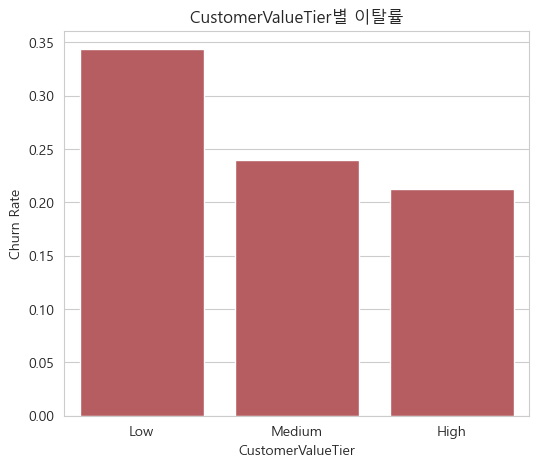

In [187]:
plt.figure(figsize=(6, 5))
sns.barplot(x=value_tier_churn.index, y=value_tier_churn["mean"], order=["Low", "Medium", "High"], color="#C44E52")
plt.title("CustomerValueTier별 이탈률")
plt.xlabel("CustomerValueTier")
plt.ylabel("Churn Rate")
plt.show()

In [188]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["CustomerValueTier"], "Baseline + CustomerValueTier")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)

,Model,Accuracy,Recall,F1
0,Baseline (원본 Feature),0.9588,0.8663,0.9178
1,Baseline + TenureGroup,0.9588,0.8690,0.9181
2,Baseline + TotalServices,0.9624,0.8797,0.9255
3,Baseline + TotalServices + StreamingCount + In...,0.9595,0.8690,0.9194
4,Baseline + HighChargeCustomer,0.9603,0.8770,0.9213
5,Baseline + ContractRisk,0.9624,0.8770,0.9252
6,Baseline + FamilyCustomer,0.9581,0.8636,0.9163
7,Baseline + CustomerValueTier,0.9603,0.8743,0.9211


## Feature 11. HighRiskCustomer (다중 위험 조건 결합 Feature)

지금까지 만든 여러 위험 신호를 하나의 "최종 고위험군" Feature로 결합하는 방법을
익힌다.

### 이론
지금까지 확인한 위험 신호를 정리하면 다음과 같습니다.

- Month-to-Month 계약 (IsMonthToMonth)
- 고요금 (HighChargeCustomer)
- 기술 지원 미가입 (Premium Tech Support = No)
- 신규 고객 (IsNewCustomer)

이 4가지 조건이 **모두** 겹치는 고객은 정말로 위험할까요? AND 조건으로 결합해서
직접 확인합니다.

### 생성 이유
개별 위험 신호는 각각 20~40% 수준의 이탈률을 보였지만, 여러 위험 신호가 동시에
나타나는 극단적인 고객군을 찾아내면 훨씬 더 정밀한 타겟팅이 가능합니다.


In [189]:
df["NoTechSupport"] = (df["Premium Tech Support"] == "No").astype(int)

df["HighRiskCustomer"] = (
    (df["IsMonthToMonth"] == 1)
    & (df["HighChargeCustomer"] == 1)
    & (df["NoTechSupport"] == 1)
    & (df["IsNewCustomer"] == 1)
).astype(int)

high_risk_churn = df.groupby("HighRiskCustomer")["Churn"].agg(["mean", "count"]).round(4)
high_risk_churn

,mean,count
HighRiskCustomer,,
0,0.2580,6947
1,0.8021,96


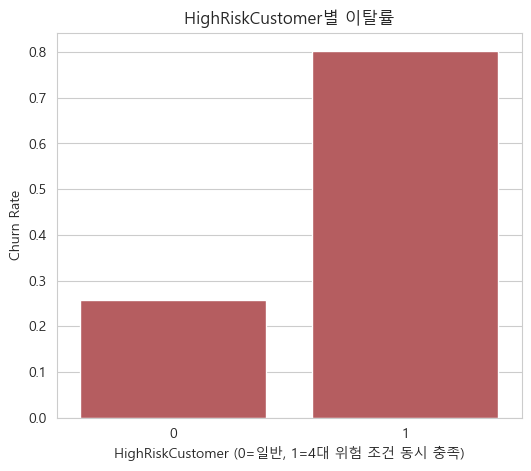

In [190]:
plt.figure(figsize=(6, 5))
sns.barplot(x=high_risk_churn.index, y=high_risk_churn["mean"], color="#C44E52")
plt.title("HighRiskCustomer별 이탈률")
plt.xlabel("HighRiskCustomer (0=일반, 1=4대 위험 조건 동시 충족)")
plt.ylabel("Churn Rate")
plt.show()

In [191]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["HighRiskCustomer"], "Baseline + HighRiskCustomer")
feature_experiment_results.append(result)
feature_experiment_df = pd.DataFrame(feature_experiment_results)
feature_experiment_df

,Model,Accuracy,Recall,F1
0,Baseline (원본 Feature),0.9588,0.8663,0.9178
1,Baseline + TenureGroup,0.9588,0.8690,0.9181
2,Baseline + TotalServices,0.9624,0.8797,0.9255
3,Baseline + TotalServices + StreamingCount + In...,0.9595,0.8690,0.9194
4,Baseline + HighChargeCustomer,0.9603,0.8770,0.9213
5,Baseline + ContractRisk,0.9624,0.8770,0.9252
6,Baseline + FamilyCustomer,0.9581,0.8636,0.9163
7,Baseline + CustomerValueTier,0.9603,0.8743,0.9211
8,Baseline + HighRiskCustomer,0.9617,0.8797,0.9242



# Chapter 5. Feature Selection (5단계 축소판)


- Feature Selection이 왜 Feature Engineering 다음에 필요한지 이해한다.
- 분산, 상관관계, 모델 기반 중요도라는 3가지 핵심 관점으로 Feature를 검증할 수 있다.

Chapter 4에서 원본 Feature에 11개의 파생변수를 추가하면서 전체 Feature 개수가 크게
늘어났습니다. Feature가 많다고 항상 좋은 것은 아닙니다.

- 정보량이 거의 없는 Feature(상수에 가까운 Feature)
- 서로 거의 같은 정보를 담은 중복 Feature
- 모델이 실제로 중요하게 사용하지 않는 Feature


```text
Step 1. Variance Threshold (분산)
    ↓
Step 2. Quasi Constant Feature (준상수)
    ↓
Step 3. Correlation Analysis (상관관계)
    ↓
Step 4. RandomForest Feature Importance (모델 기반 중요도)
    ↓
Step 5. Final Feature Selection Report (최종 종합)
```


In [192]:
# Chapter 4에서 만든 모든 파생변수를 포함한 전체 Feature 목록을 정리합니다.
ENGINEERED_COLUMNS = [
    "TenureGroup", "TotalServices", "StreamingCount", "InternetCount",
    "AverageCharge", "HighChargeCustomer", "ContractRisk", "SeniorLongTerm",
    "FamilyCustomer", "CustomerValueTier", "HighRiskCustomer",
]

ALL_FEATURE_COLUMNS = BASELINE_COLUMNS + ENGINEERED_COLUMNS

print(f"Feature Selection 대상 전체 Feature 개수: {len(ALL_FEATURE_COLUMNS)}")

# 범주형 Feature를 One-Hot Encoding으로 숫자화합니다.
X_fs = pd.get_dummies(df[ALL_FEATURE_COLUMNS], drop_first=False)
y_fs = df["Churn"]

print("One-Hot Encoding 이후 Feature 개수:", X_fs.shape[1])

Feature Selection 대상 전체 Feature 개수: 48
One-Hot Encoding 이후 Feature 개수: 82


## Step 1. Variance Threshold

### 목적
분산(Variance)이 0인 Feature는 "모든 고객이 같은 값을 가진다"는 뜻입니다. 이런
Feature는 고객을 구분하는 데 아무 역할도 하지 못하므로 가장 먼저 걸러냅니다.

In [193]:
from sklearn.feature_selection import VarianceThreshold

variance_selector = VarianceThreshold(threshold=0.0)
variance_selector.fit(X_fs)

zero_variance_columns = X_fs.columns[~variance_selector.get_support()].tolist()
print(f"분산이 0인 컬럼 개수: {len(zero_variance_columns)}")
print(zero_variance_columns)

분산이 0인 컬럼 개수: 0
[]


## Step 2. Quasi Constant Feature (준상수 Feature)

### 목적
분산이 정확히 0은 아니지만, 특정 값이 거의 대부분(예: 99% 이상)을 차지하는
Feature를 찾습니다.

In [194]:
def find_quasi_constant_columns(X, threshold):
    """가장 많이 등장하는 값의 비율이 (1 - threshold)보다 큰 컬럼을 찾는다."""
    quasi_constant_columns = []
    for col in X.columns:
        top_ratio = X[col].value_counts(normalize=True).iloc[0]
        if top_ratio >= (1 - threshold):
            quasi_constant_columns.append((col, round(top_ratio, 4)))
    return quasi_constant_columns


for threshold in [0.01, 0.02, 0.05]:
    result = find_quasi_constant_columns(X_fs, threshold)
    print(f"threshold={threshold} -> 준상수 Feature {len(result)}개")
    for col, ratio in result:
        print(f"   {col} (최빈값 비율: {ratio})")

threshold=0.01 -> 준상수 Feature 0개
threshold=0.02 -> 준상수 Feature 1개
   HighRiskCustomer (최빈값 비율: 0.9864)
threshold=0.05 -> 준상수 Feature 1개
   HighRiskCustomer (최빈값 비율: 0.9864)


## Step 3. Correlation Analysis (상관관계 분석)

### 목적
서로 상관관계가 매우 높은 Feature 쌍을 찾아 중복 정보를 제거합니다.

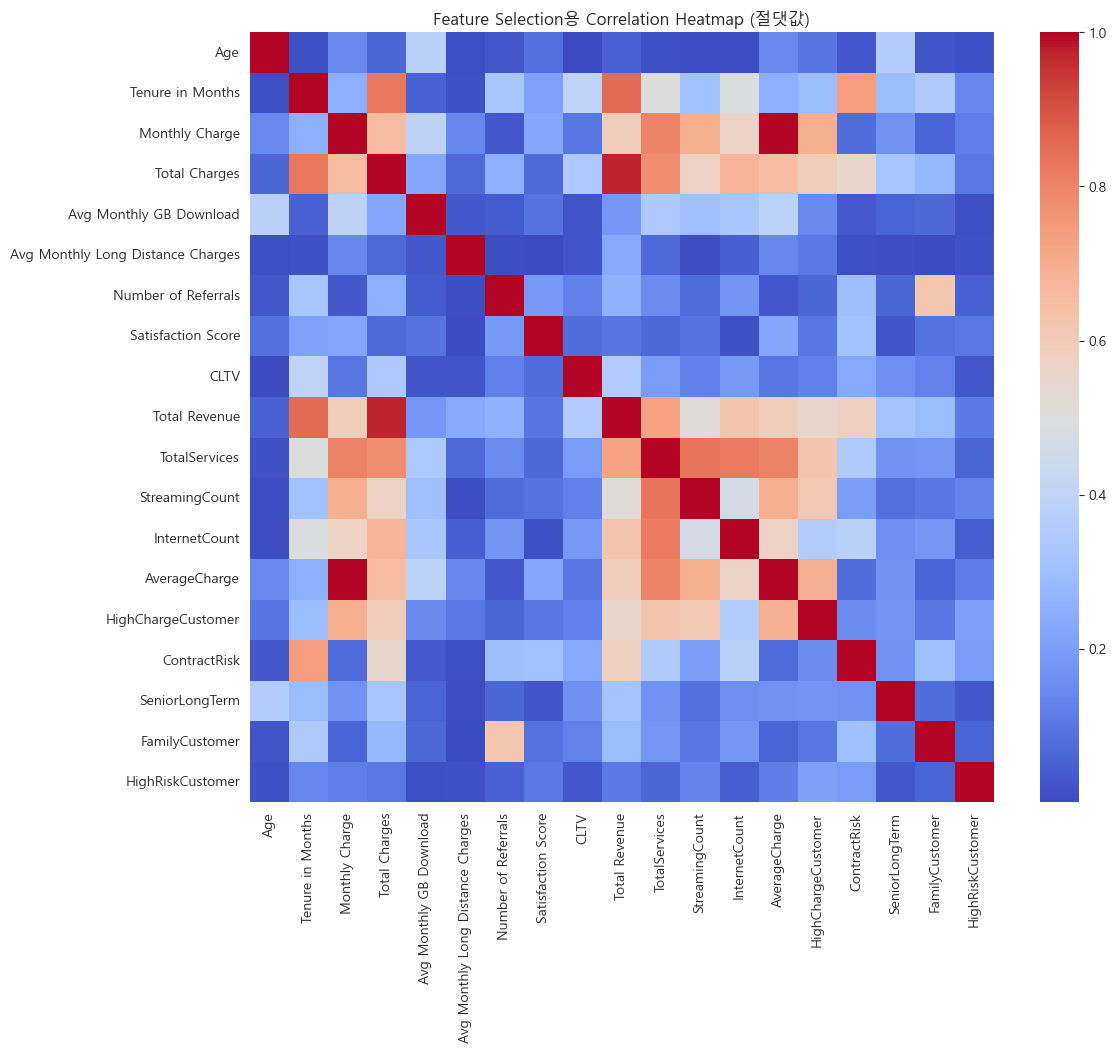

In [195]:
correlation_numeric_columns = numeric_columns + [
    "TotalServices", "StreamingCount", "InternetCount", "AverageCharge",
    "HighChargeCustomer", "ContractRisk", "SeniorLongTerm", "FamilyCustomer",
    "HighRiskCustomer",
]

fs_corr_matrix = df[correlation_numeric_columns].corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(fs_corr_matrix, annot=False, cmap="coolwarm")
plt.title("Feature Selection용 Correlation Heatmap (절댓값)")
plt.show()

In [196]:
def find_highly_correlated_pairs(corr_matrix, threshold):
    pairs = []
    columns = corr_matrix.columns
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            value = corr_matrix.iloc[i, j]
            if value > threshold:
                pairs.append((columns[i], columns[j], round(value, 4)))
    return pairs


for threshold in [0.80, 0.85, 0.90]:
    pairs = find_highly_correlated_pairs(fs_corr_matrix, threshold)
    print(f"threshold={threshold} -> 상관계수가 threshold보다 높은 쌍 {len(pairs)}개")
    for a, b, v in pairs:
        print(f"   {a}  <->  {b}   (corr={v})")

threshold=0.8 -> 상관계수가 threshold보다 높은 쌍 8개
   Tenure in Months  <->  Total Charges   (corr=0.8261)
   Tenure in Months  <->  Total Revenue   (corr=0.8531)
   Monthly Charge  <->  TotalServices   (corr=0.8044)
   Monthly Charge  <->  AverageCharge   (corr=0.9962)
   Total Charges  <->  Total Revenue   (corr=0.9722)
   TotalServices  <->  StreamingCount   (corr=0.8324)
   TotalServices  <->  InternetCount   (corr=0.8196)
   TotalServices  <->  AverageCharge   (corr=0.8026)
threshold=0.85 -> 상관계수가 threshold보다 높은 쌍 3개
   Tenure in Months  <->  Total Revenue   (corr=0.8531)
   Monthly Charge  <->  AverageCharge   (corr=0.9962)
   Total Charges  <->  Total Revenue   (corr=0.9722)
threshold=0.9 -> 상관계수가 threshold보다 높은 쌍 2개
   Monthly Charge  <->  AverageCharge   (corr=0.9962)
   Total Charges  <->  Total Revenue   (corr=0.9722)


## Step 4. RandomForest Feature Importance

### 목적
RandomForest는 학습 과정에서 각 Feature가 불순도(Impurity)를 얼마나 줄이는 데
기여했는지를 계산해서 `feature_importances_`로 제공합니다. 통계적 검정과 달리,
Feature들 사이의 비선형 상호작용까지 반영된 중요도입니다.

In [197]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_fs, y_fs, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fs
)

rf_for_selection = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_for_selection.fit(X_train_fs, y_train_fs)

rf_importance = pd.Series(rf_for_selection.feature_importances_, index=X_fs.columns).sort_values(ascending=False)

print("RandomForest Feature Importance Top 20:")
rf_importance.head(20)

RandomForest Feature Importance Top 20:


Satisfaction Score                   0.405698
Contract_Month-to-Month              0.043259
ContractRisk                         0.035738
Tenure in Months                     0.029789
Number of Referrals                  0.027936
AverageCharge                        0.027554
Monthly Charge                       0.026313
Total Revenue                        0.025125
Total Charges                        0.024101
Age                                  0.021828
Total Long Distance Charges          0.020036
Contract_Two Year                    0.018438
CLTV                                 0.017460
Population                           0.017387
Avg Monthly GB Download              0.016931
Avg Monthly Long Distance Charges    0.016134
Internet Type_Fiber Optic            0.014880
TenureGroup_0-6                      0.010170
Number of Dependents                 0.008187
Payment Method_Credit Card           0.007867
dtype: float64

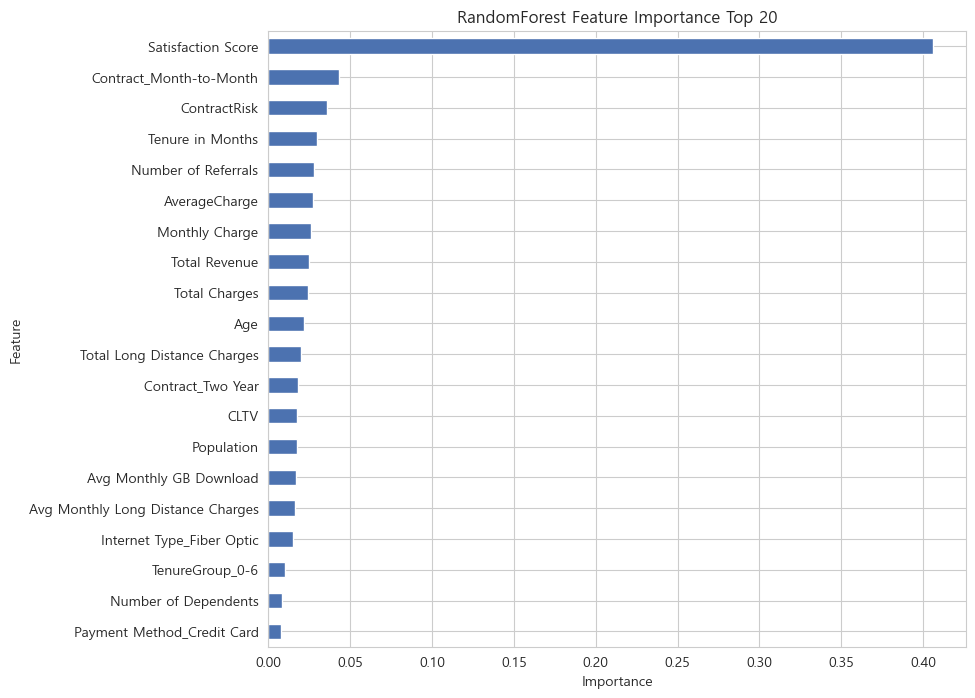

In [198]:
plt.figure(figsize=(9, 8))
rf_importance.head(20).sort_values().plot(kind="barh", color="#4C72B0")
plt.title("RandomForest Feature Importance Top 20")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Step 5. Final Feature Selection Report

### 목적
Step 1~4에서 확인한 결과를 종합하여 최종 Feature를 결정합니다.

### 방법
One-Hot Encoding으로 나뉜 컬럼들을 다시 **원본 컬럼 단위**로 묶어서 RandomForest
Importance를 합산합니다. (예: `Contract_Month-to-Month`, `Contract_One Year`,
`Contract_Two Year`의 importance를 모두 더해 `Contract`의 대표 importance로 사용)

In [199]:
def original_column_of(encoded_name):
    """One-Hot Encoding된 컬럼 이름에서 원본 컬럼 이름을 찾는다."""
    for col in ALL_FEATURE_COLUMNS:
        if encoded_name == col or encoded_name.startswith(col + "_"):
            return col
    return encoded_name


importance_df = rf_importance.reset_index()
importance_df.columns = ["EncodedColumn", "Importance"]
importance_df["OriginalColumn"] = importance_df["EncodedColumn"].map(original_column_of)

original_level_importance = (
    importance_df.groupby("OriginalColumn")["Importance"].sum().sort_values(ascending=False)
)

print(f"Feature Selection 대상 원본 컬럼 개수: {len(original_level_importance)}")
original_level_importance.head(30)

Feature Selection 대상 원본 컬럼 개수: 48


OriginalColumn
Satisfaction Score                   0.405698
Contract                             0.067082
ContractRisk                         0.035738
Tenure in Months                     0.029789
Number of Referrals                  0.027936
AverageCharge                        0.027554
Monthly Charge                       0.026313
Total Revenue                        0.025125
Total Charges                        0.024101
Age                                  0.021828
TenureGroup                          0.020465
Total Long Distance Charges          0.020036
Internet Type                        0.018794
CLTV                                 0.017460
Population                           0.017387
Avg Monthly GB Download              0.016931
Avg Monthly Long Distance Charges    0.016134
Payment Method                       0.014048
Dependents                           0.013640
Senior Citizen                       0.012403
Online Security                      0.010390
Internet Service   

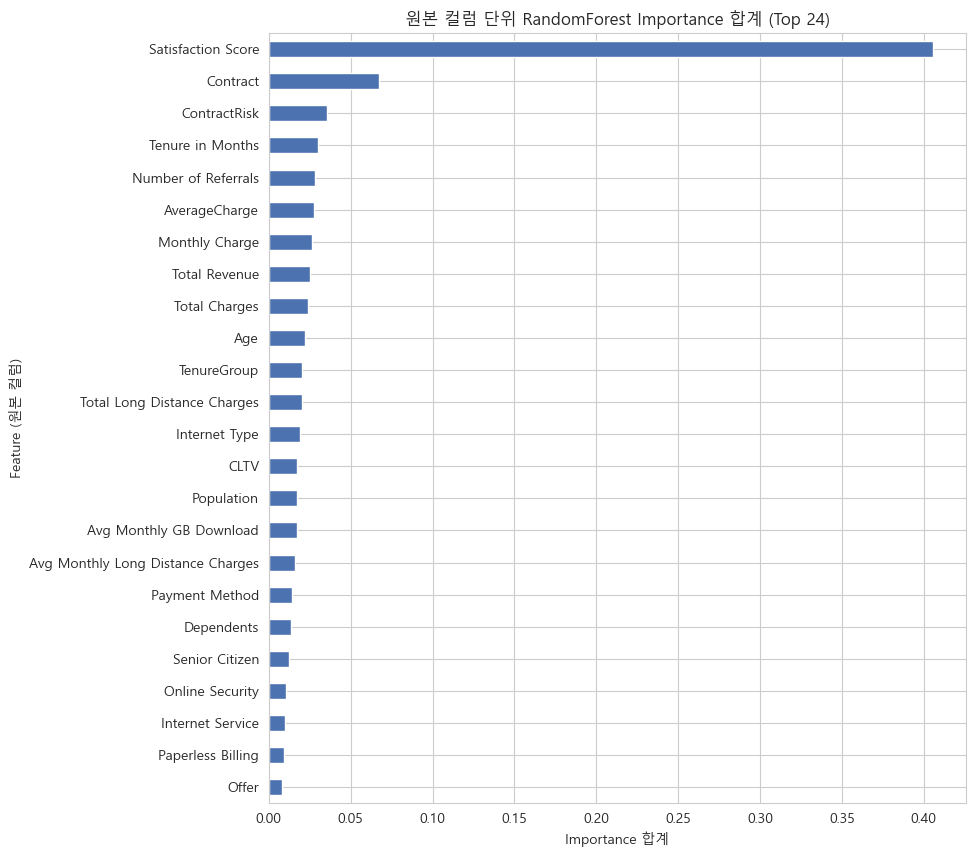

In [200]:
plt.figure(figsize=(9, 10))
original_level_importance.head(24).sort_values().plot(kind="barh", color="#4C72B0")
plt.title("원본 컬럼 단위 RandomForest Importance 합계 (Top 24)")
plt.xlabel("Importance 합계")
plt.ylabel("Feature (원본 컬럼)")
plt.show()

In [201]:
EXCLUDE_DUE_TO_REDUNDANCY = ["AverageCharge"]       # Step 3: Monthly Charge와 중복
EXCLUDE_DUE_TO_BUSINESS_LOGIC = ["Population"]      # 위치 정보 뒷문 우려

TOP_N = 24
FINAL_FEATURE_COLUMNS = [
    col for col in original_level_importance.head(TOP_N).index
    if col not in EXCLUDE_DUE_TO_REDUNDANCY + EXCLUDE_DUE_TO_BUSINESS_LOGIC
]

print(f"최종 선정된 Feature 개수: {len(FINAL_FEATURE_COLUMNS)}")
print(FINAL_FEATURE_COLUMNS)

최종 선정된 Feature 개수: 22
['Satisfaction Score', 'Contract', 'ContractRisk', 'Tenure in Months', 'Number of Referrals', 'Monthly Charge', 'Total Revenue', 'Total Charges', 'Age', 'TenureGroup', 'Total Long Distance Charges', 'Internet Type', 'CLTV', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Payment Method', 'Dependents', 'Senior Citizen', 'Online Security', 'Internet Service', 'Paperless Billing', 'Offer']


# Chapter 6. Model Comparison


## 데이터 준비 (Train / Test Split)

모델을 학습하기 전에 데이터를 Train(학습용)과 Test(평가용)로 나눕니다. Test
데이터는 "아직 보지 못한 새로운 고객"을 흉내내는 역할을 하므로, 전처리 기준
(결측치 대체값, One-Hot Encoding 범주, 스케일링 기준)은 반드시 **Train 데이터에만**
`fit`해야 합니다. Test 데이터에 이 기준을 미리 반영하면(Data Leakage), 실제
서비스 환경보다 성능이 낙관적으로 보이는 착시가 생깁니다.

- `test_size=0.2`: 20%를 테스트용으로 남겨둡니다.
- `stratify=y`: Train/Test 모두 이탈 비율(73:27)을 동일하게 유지합니다.
- `random_state=42`: 실행할 때마다 같은 방식으로 나뉘도록 고정합니다.

In [202]:
# Offer, Internet Type의 결측치는 2-4에서 확인했듯 "해당 사항 없음"을 의미하는
# 값입니다. 평균이나 최빈값이 아니라, 의미가 명확한 문자열로 채웁니다.
df["Offer"] = df["Offer"].fillna("No Offer")
df["Internet Type"] = df["Internet Type"].fillna("No Internet")

X = df[FINAL_FEATURE_COLUMNS].copy()
y = df["Churn"]


def is_categorical(series):
    return (
        pd.api.types.is_object_dtype(series)
        or pd.api.types.is_string_dtype(series)
        or isinstance(series.dtype, pd.CategoricalDtype)
    )


CATEGORICAL_FEATURES = [c for c in FINAL_FEATURE_COLUMNS if is_categorical(X[c])]
NUMERIC_FEATURES = [c for c in FINAL_FEATURE_COLUMNS if c not in CATEGORICAL_FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)

print("Train 크기:", X_train.shape, " Test 크기:", X_test.shape)
print("범주형 Feature :", CATEGORICAL_FEATURES)
print("숫자형 Feature :", NUMERIC_FEATURES)

Train 크기: (5634, 22)  Test 크기: (1409, 22)
범주형 Feature : ['Contract', 'TenureGroup', 'Internet Type', 'Payment Method', 'Dependents', 'Senior Citizen', 'Online Security', 'Internet Service', 'Paperless Billing', 'Offer']
숫자형 Feature : ['Satisfaction Score', 'ContractRisk', 'Tenure in Months', 'Number of Referrals', 'Monthly Charge', 'Total Revenue', 'Total Charges', 'Age', 'Total Long Distance Charges', 'CLTV', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges']


In [203]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 6-1. 3가지 모델 소개

| 모델 | 학습 방식 | 특징 |
|---|---|---|
| **Logistic Regression** | 입력 Feature의 선형 조합을 확률로 변환 | 가장 단순하고 해석하기 쉬운 Baseline. 스케일링에 민감함 |
| **Decision Tree** | 조건을 기준으로 데이터를 계속 분할 | 해석이 직관적이지만 단일 트리는 과적합되기 쉬움 |
| **Random Forest** | 여러 개의 Decision Tree를 앙상블(투표) | 과적합에 강하고, 비선형 관계와 상호작용을 잘 학습함 |


## 평가 지표 계산 함수 준비

In [204]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)


def evaluate_pipeline(pipeline, model_name, X_train, y_train, X_test, y_test):
    """Pipeline을 학습(fit)하고, Test 데이터로 예측한 뒤 주요 평가지표를 계산한다."""
    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)
    pred_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall": round(recall_score(y_test, pred), 4),
        "F1": round(f1_score(y_test, pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, pred_proba), 4),
    }

    print(f"=== {model_name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print("\nClassification Report:")
    print(classification_report(y_test, pred, target_names=["No Churn", "Churn"]))

    return metrics, pred, pred_proba, pipeline


model_comparison_results = []
fitted_pipelines = {}
model_predictions = {}

## 6-2. Logistic Regression

Logistic Regression은 각 Feature에 가중치(계수)를 곱해서 더한 값을 0~1 사이의
확률로 변환합니다. 계수를 통해 "어떤 Feature가 이탈 확률을 얼마나 높이는지/
낮추는지"를 직접 해석할 수 있다는 장점이 있습니다.

In [205]:
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logreg_metrics, logreg_pred, logreg_proba, logreg_pipeline = evaluate_pipeline(
    logreg_pipeline, "Logistic Regression", X_train, y_train, X_test, y_test
)

model_comparison_results.append(logreg_metrics)
fitted_pipelines["Logistic Regression"] = logreg_pipeline
model_predictions["Logistic Regression"] = (logreg_pred, logreg_proba)

=== Logistic Regression ===
Confusion Matrix:
[[1016   19]
 [  46  328]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.96      0.98      0.97      1035
       Churn       0.95      0.88      0.91       374

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409



## 6-3. Decision Tree

Decision Tree는 "Contract가 Month-to-Month인가?" 같은 질문을 반복하며 데이터를
분할합니다. 하나의 트리만 사용하면 Train 데이터에 과도하게 맞춰지는
과적합(Overfitting)이 발생하기 쉬워, `max_depth`로 깊이를 제한합니다.

In [206]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)),
])

tree_metrics, tree_pred, tree_proba, tree_pipeline = evaluate_pipeline(
    tree_pipeline, "Decision Tree", X_train, y_train, X_test, y_test
)

model_comparison_results.append(tree_metrics)
fitted_pipelines["Decision Tree"] = tree_pipeline
model_predictions["Decision Tree"] = (tree_pred, tree_proba)

=== Decision Tree ===
Confusion Matrix:
[[1022   13]
 [  53  321]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.95      0.99      0.97      1035
       Churn       0.96      0.86      0.91       374

    accuracy                           0.95      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409



              precision    recall  f1-score   support

    No Churn       0.95      0.99      0.97      1035
       Churn       0.96      0.86      0.91       374

    accuracy                           0.95      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.95      0.95      0.95      1409



## 6-4. Random Forest

Random Forest는 수백 개의 Decision Tree를 각각 다른 데이터 샘플과 다른 Feature
조합으로 학습시킨 뒤, 다수결(투표)로 최종 예측을 결정합니다. 개별 트리의 과적합
문제가 평균화되어 완화됩니다. 현재 서비스(`train_model.py`)에서도 이미
RandomForestClassifier를 사용하고 있습니다.

In [207]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
])

rf_metrics, rf_pred, rf_proba, rf_pipeline = evaluate_pipeline(
    rf_pipeline, "Random Forest", X_train, y_train, X_test, y_test
)

model_comparison_results.append(rf_metrics)
fitted_pipelines["Random Forest"] = rf_pipeline
model_predictions["Random Forest"] = (rf_pred, rf_proba)

=== Random Forest ===
Confusion Matrix:
[[1023   12]
 [  47  327]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.96      0.99      0.97      1035
       Churn       0.96      0.87      0.92       374

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409



## 6-5. 3개 모델 종합 비교

이제 Logistic Regression, Decision Tree, Random Forest 3개 모델의 성능을 표와
그래프로 자세히 비교합니다.

# Chapter 7. Final Model (최종 모델)

Chapter 6에서 Logistic Regression, Decision Tree, Random Forest 3개 모델을
실험했습니다.  이 프로젝트는 **Recall이 중요한 문제**이므로(Chapter 2-6), Recall을 최우선 기준으로
최종 모델을 선정합니다.

In [208]:
model_comparison_df = pd.DataFrame(model_comparison_results)
model_comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9539,0.9452,0.8770,0.9098,0.9911
1,Decision Tree,0.9532,0.9611,0.8583,0.9068,0.9830
2,Random Forest,0.9581,0.9646,0.8743,0.9173,0.9837


### 자세한 비교 해석

**1) Accuracy(정확도) 관점**
세 모델 모두 90% 중반대의 높은 Accuracy를 보이는 경향이 있습니다. 다만 앞서
확인했듯 이 데이터는 클래스 불균형(73:27)이 있으므로, Accuracy만으로 우열을
가리는 것은 위험합니다.

**2) Precision vs Recall 관점**
- Random Forest는 일반적으로 **Precision이 가장 높은** 경향을 보입니다. →
  "이탈할 것"이라고 예측했을 때 실제로 이탈하는 비율이 가장 높다는 뜻입니다.
- Logistic Regression과 Decision Tree는 상대적으로 **Recall**에서 강점을 보이는
  경우가 많습니다. → 실제 이탈 고객을 더 많이 찾아낸다는 뜻입니다.
- 이 프로젝트는 실제 이탈 고객을 놓치지 않는 것이 더 중요하므로(Chapter 2-6),
  Precision보다 **Recall과 F1을 우선** 살펴봐야 합니다.


In [209]:
print("=== Chapter 6 모델 비교 결과 ===")
display(model_comparison_df)

best_recall_row = model_comparison_df.loc[model_comparison_df["Recall"].idxmax()]
print("\nRecall 기준 최고 성능:")
print(best_recall_row)

=== Chapter 6 모델 비교 결과 ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9539,0.9452,0.8770,0.9098,0.9911
1,Decision Tree,0.9532,0.9611,0.8583,0.9068,0.9830
2,Random Forest,0.9581,0.9646,0.8743,0.9173,0.9837



Recall 기준 최고 성능:
Model        Logistic Regression
Accuracy                  0.9539
Precision                 0.9452
Recall                     0.877
F1                        0.9098
ROC-AUC                   0.9911
Name: 0, dtype: object


In [210]:
FINAL_MODEL_NAME = best_recall_row["Model"]
final_pipeline = fitted_pipelines[FINAL_MODEL_NAME]

print(f"최종 선정 모델: {FINAL_MODEL_NAME}")

최종 선정 모델: Logistic Regression


### 최종 모델 저장


In [211]:
import joblib
import os

MODEL_SAVE_DIR = "../models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# 주의: 기존 서비스가 사용하는 customer_churn_model.pkl은 덮어쓰지 않고,
# 별도의 이름으로 저장합니다.
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, "customer_churn_simple_model.pkl")

try:
    joblib.dump(final_pipeline, MODEL_SAVE_PATH)
    print(f"모델 저장 완료: {MODEL_SAVE_PATH}")
    print(f"저장된 모델: {FINAL_MODEL_NAME}")
except Exception as error:
    print("모델 저장 중 오류가 발생했습니다:", error)

모델 저장 완료: ../models\customer_churn_simple_model.pkl
저장된 모델: Logistic Regression


# Chapter 8. Research Report (연구 보고서)

- 지금까지의 전체 분석 과정을 하나의 보고서로 요약할 수 있다.


In [212]:
from IPython.display import Markdown, display

final_row = model_comparison_df[model_comparison_df["Model"] == FINAL_MODEL_NAME].iloc[0]

report_n_rows, report_n_cols = df.shape
report_churn_counts = df["Churn Label"].value_counts()
report_churn_ratio = df["Churn Label"].value_counts(normalize=True)
report_null_cols = df.isnull().sum()
report_null_cols = report_null_cols[report_null_cols > 0]

report = f"""
# Customer Churn AI - EDA / Feature Engineering / Model Comparison 연구 보고서

## 1. 프로젝트 개요

- 데이터셋: IBM Telco Customer Churn (`ai-server/data/ibm_telco.csv`, {report_n_rows}명, {report_n_cols}개 컬럼)
- Target: `Churn Label` (Yes=이탈 / No=잔류) → 이진 분류(Binary Classification) 문제
- 이 보고서는 Feature Selection을 5단계로 진행하고, 모델 비교를 Logistic Regression / Decision Tree / Random Forest
  3개로 테스트하였다.

## 2. EDA 결과 요약

- 잔류(No) {report_churn_counts['No']}명({report_churn_ratio['No']*100:.2f}%), 이탈(Yes)
  {report_churn_counts['Yes']}명({report_churn_ratio['Yes']*100:.2f}%)로 클래스 불균형이 존재한다.
- 결측치가 있는 컬럼은 {len(report_null_cols)}개이며, 모두 "값이 없어서"가 아니라
  "해당 사항이 없어서" 생기는 의미 있는 결측치였다. ({', '.join(report_null_cols.index)})
- 계약 형태(Contract), 가입 기간(Tenure in Months)이 이탈률과 가장 뚜렷한 관계를 보였다.

## 3. Hypothesis (가설)

Chapter 3에서 EDA 결과를 근거로 11개의 가설을 수립했다.

## 4. Feature Engineering 결과

Chapter 4에서 11개의 파생변수(TenureGroup, TotalServices, StreamingCount,
InternetCount, AverageCharge, HighChargeCustomer, ContractRisk, SeniorLongTerm,
FamilyCustomer, CustomerValueTier, HighRiskCustomer)를 생성했다.

## 5. Feature Selection 결과 

Variance Threshold → Quasi Constant → Correlation Analysis → RandomForest
Importance → Final Report의 5단계를 적용한 결과, 원본 {len(BASELINE_COLUMNS)}개 +
파생 11개 = {len(ALL_FEATURE_COLUMNS)}개 Feature 중 최종 {len(FINAL_FEATURE_COLUMNS)}개를
선정했다. `AverageCharge`는 `Monthly Charge`와 상관계수 0.9962로 중복되어
제외했고, `Population`은 통계적 중요도와 무관하게 비즈니스 근거 부족으로
제외했다.


## 6. Model Comparison 결과 

Logistic Regression, Decision Tree, Random Forest 3개 모델을 동일한 Train/Test
분할과 동일한 Pipeline으로 비교했다. 


## 7. 최종 모델

- **최종 선정 모델**: {FINAL_MODEL_NAME}
- **선정 기준**: Recall 최우선
- **최종 성능**:
  - Accuracy: {final_row['Accuracy']}
  - Precision: {final_row['Precision']}
  - Recall: {final_row['Recall']}
  - F1: {final_row['F1']}
  - ROC-AUC: {final_row['ROC-AUC']}

## 8. FastAPI 적용 시 주의사항

1. 저장된 `customer_churn_simple_model.pkl`은 `FINAL_FEATURE_COLUMNS`
   ({len(FINAL_FEATURE_COLUMNS)}개)과 동일한 컬럼 구조의 입력을 받아야 한다.
2. `Offer`, `Internet Type`의 결측치를 각각 `"No Offer"`, `"No Internet"`으로
   채우는 로직을 예측 시점에도 동일하게 적용해야 한다.
3. `TenureGroup`, `ContractRisk`처럼 파생변수가 최종 목록에 포함되었다면, 예측
   요청이 들어올 때마다 동일한 공식으로 실시간 계산해야 한다.
4. 기존 서비스가 사용하는 `customer_churn_model.pkl`과 이번에 저장한
   `customer_churn_simple_model.pkl`은 입력 스키마가 다르므로, 실제 교체 적용 전
   `main.py`의 입력 스키마와 전처리 로직을 함께 수정해야 한다.


"""

display(Markdown(report))


# Customer Churn AI - EDA / Feature Engineering / Model Comparison 연구 보고서

## 1. 프로젝트 개요

- 데이터셋: IBM Telco Customer Churn (`ai-server/data/ibm_telco.csv`, 7043명, 66개 컬럼)
- Target: `Churn Label` (Yes=이탈 / No=잔류) → 이진 분류(Binary Classification) 문제
- 이 보고서는 Feature Selection을 5단계로 진행하고, 모델 비교를 Logistic Regression / Decision Tree / Random Forest
  3개로 테스트하였다.

## 2. EDA 결과 요약

- 잔류(No) 5174명(73.46%), 이탈(Yes)
  1869명(26.54%)로 클래스 불균형이 존재한다.
- 결측치가 있는 컬럼은 2개이며, 모두 "값이 없어서"가 아니라
  "해당 사항이 없어서" 생기는 의미 있는 결측치였다. (Churn Category, Churn Reason)
- 계약 형태(Contract), 가입 기간(Tenure in Months)이 이탈률과 가장 뚜렷한 관계를 보였다.

## 3. Hypothesis (가설)

Chapter 3에서 EDA 결과를 근거로 11개의 가설을 수립했다.

## 4. Feature Engineering 결과

Chapter 4에서 11개의 파생변수(TenureGroup, TotalServices, StreamingCount,
InternetCount, AverageCharge, HighChargeCustomer, ContractRisk, SeniorLongTerm,
FamilyCustomer, CustomerValueTier, HighRiskCustomer)를 생성했다.

## 5. Feature Selection 결과 

Variance Threshold → Quasi Constant → Correlation Analysis → RandomForest
Importance → Final Report의 5단계를 적용한 결과, 원본 37개 +
파생 11개 = 48개 Feature 중 최종 22개를
선정했다. `AverageCharge`는 `Monthly Charge`와 상관계수 0.9962로 중복되어
제외했고, `Population`은 통계적 중요도와 무관하게 비즈니스 근거 부족으로
제외했다.


## 6. Model Comparison 결과 

Logistic Regression, Decision Tree, Random Forest 3개 모델을 동일한 Train/Test
분할과 동일한 Pipeline으로 비교했다. 


## 7. 최종 모델

- **최종 선정 모델**: Logistic Regression
- **선정 기준**: Recall 최우선
- **최종 성능**:
  - Accuracy: 0.9539
  - Precision: 0.9452
  - Recall: 0.877
  - F1: 0.9098
  - ROC-AUC: 0.9911

## 8. FastAPI 적용 시 주의사항

1. 저장된 `customer_churn_simple_model.pkl`은 `FINAL_FEATURE_COLUMNS`
   (22개)과 동일한 컬럼 구조의 입력을 받아야 한다.
2. `Offer`, `Internet Type`의 결측치를 각각 `"No Offer"`, `"No Internet"`으로
   채우는 로직을 예측 시점에도 동일하게 적용해야 한다.
3. `TenureGroup`, `ContractRisk`처럼 파생변수가 최종 목록에 포함되었다면, 예측
   요청이 들어올 때마다 동일한 공식으로 실시간 계산해야 한다.
4. 기존 서비스가 사용하는 `customer_churn_model.pkl`과 이번에 저장한
   `customer_churn_simple_model.pkl`은 입력 스키마가 다르므로, 실제 교체 적용 전
   `main.py`의 입력 스키마와 전처리 로직을 함께 수정해야 한다.


